In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'distance_at_head_turn_2_index'] = np.nan
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.array(peaks).astype(object)
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)

In [130]:
row.num_turn

1.0

In [129]:
row.distance_at_head_turn_2_indexs

array([4], dtype=object)

In [3]:
def towards_away_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_corner_angle_velocity[:int(row.obstacle_ind)], width=1,height=(2,12))
        neg_peaks, neg_prop = find_peaks((row.head_corner_angle_velocity[:int(row.obstacle_ind)])*-1, width=1,height=(2,12))
        if len(pos_peaks) == 0:
            df.at[ind,'towards_num_turn'] = 0
        elif len(neg_peaks) == 0: 
            df.at[ind,'away_num_turn'] = 0  
        else:
            df.at[ind,'towards_num_turn'] = len(pos_peaks)
            df.at[ind,'away_num_turn'] = len(neg_peaks)

In [4]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
angular_velocity_head_corner(joint)
distance_at_head_turn_2(joint)
towards_away_turns(joint)
distance_at_head_turn_2(joint)
#con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

<AxesSubplot: xlabel='task', ylabel='num_turn'>

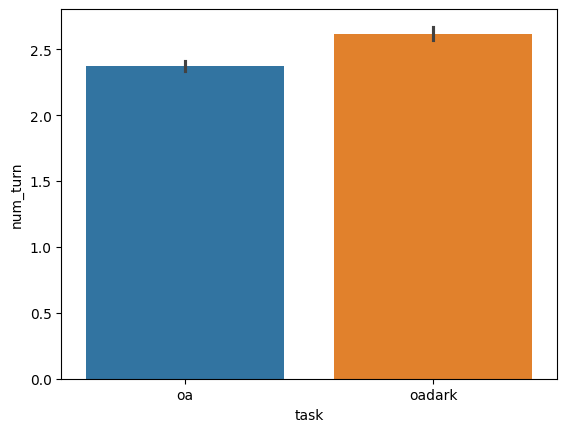

In [102]:
data = joint[joint.turn_to_obstacle == 'towards']
data = data.drop(columns=['level_0'])
data = data.reset_index()
sns.barplot(data = data[data.num_turn<=10],x = 'task',y ='num_turn',hue='task')

<AxesSubplot: xlabel='task', ylabel='towards_num_turn'>

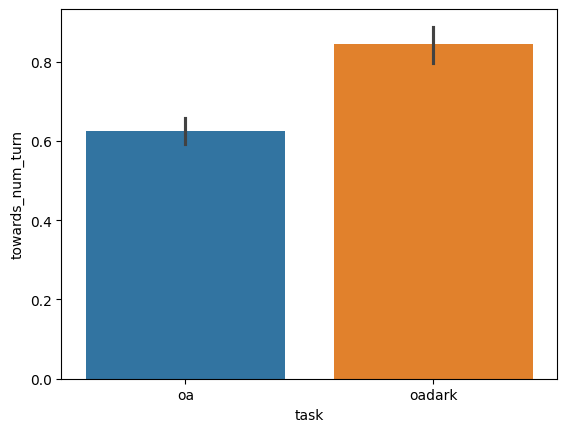

In [81]:
data = long_nostart
data = data.drop(columns=['level_0'])
data = data.reset_index()
sns.barplot(data = data,x = 'task',y ='towards_num_turn',hue='task')

<AxesSubplot: ylabel='away_num_turn'>

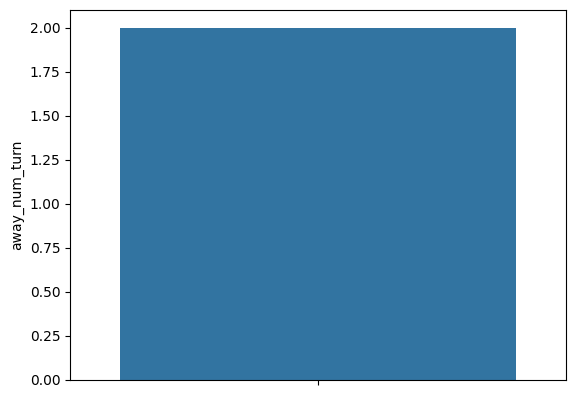

In [96]:
light = long_nostart[long_nostart.task == 'oa']
sns.barplot( data = light,y = 'away_num_turn',estimator='median')

<AxesSubplot: ylabel='away_num_turn'>

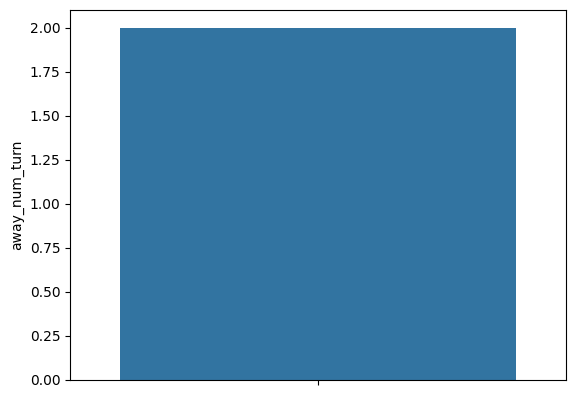

In [95]:
dark = long_nostart[long_nostart.task == 'oadark']
sns.barplot( data = dark,y = 'away_num_turn',estimator='median')

<AxesSubplot: xlabel='num_turn', ylabel='Proportion'>

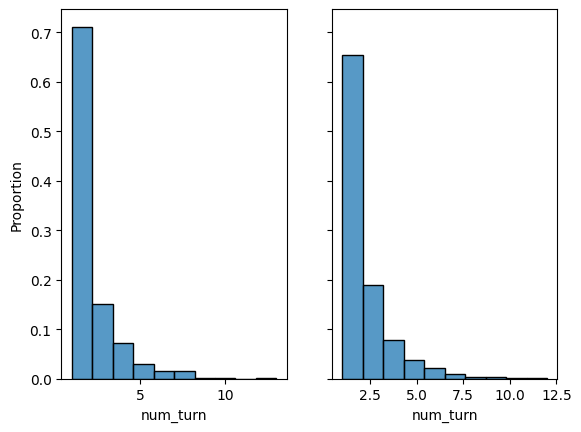

In [104]:
fig,ax = plt.subplots(1,2,sharey=True)
light = joint[joint.task == 'oa']
dark = joint[joint.task == 'oadark']

sns.histplot(ax =ax[0], data = light[light.num_turn>0],x = 'num_turn',stat='proportion',bins = 10)
sns.histplot(ax =ax[1], data = dark[dark.num_turn>0],x = 'num_turn',stat='proportion',bins = 10)

<AxesSubplot: xlabel='away_num_turn', ylabel='Proportion'>

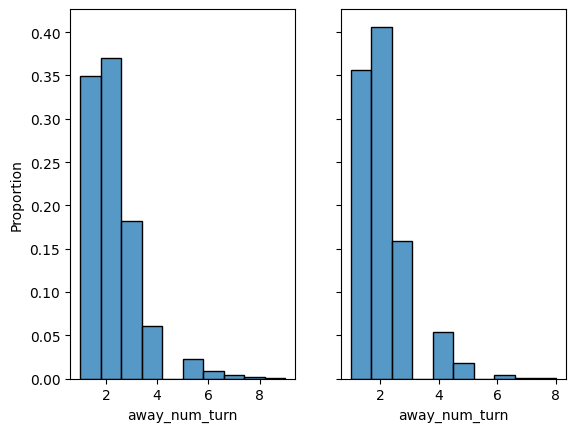

In [99]:
fig,ax = plt.subplots(1,2,sharey=True)
light = joint[joint.task == 'oa']
dark = joint[joint.task == 'oadark']

sns.histplot(ax =ax[0], data = light[light.away_num_turn>0],x = 'away_num_turn',stat='proportion',bins = 10)
sns.histplot(ax =ax[1], data = dark[dark.away_num_turn>0],x = 'away_num_turn',stat='proportion',bins = 10)

<ErrorbarContainer object of 3 artists>

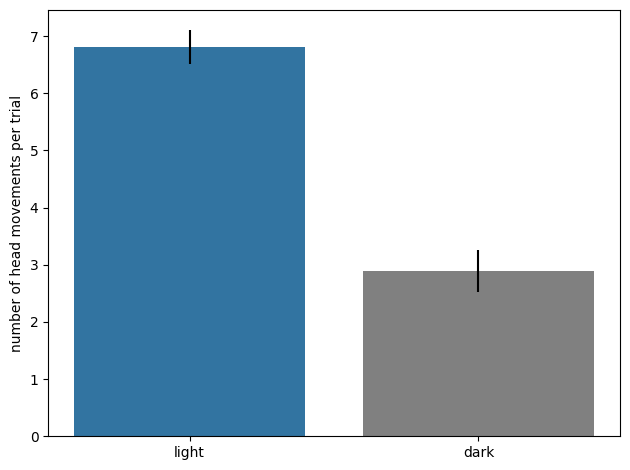

In [113]:
fig,ax = plt.subplots(layout = 'tight')
data = pd.concat([long_nostart,short_nostart])
data = data[data.turn_to_obstacle=='towards']
sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'task',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_median = light.distance_at_head_turn_2.median()
light_after= np.nanstd(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

dark = data[data.task == 'oadark']
dark_median = dark.distance_at_head_turn_2.median()
dark_after= np.nanstd(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

ax.errorbar([0,1],[light_median,dark_median] , yerr=[light_after,dark_after], ls='none' ,color="black")


<ErrorbarContainer object of 3 artists>

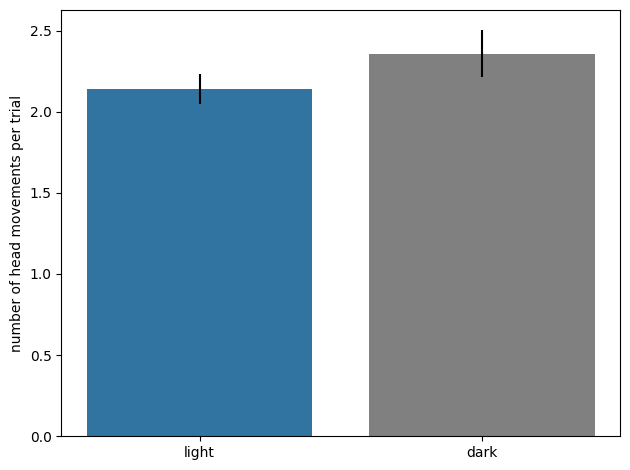

In [106]:
fig,ax = plt.subplots(layout = 'tight')
data = pd.concat([long_nostart,short_nostart])
data = data[data.time<=10]
sns.barplot(ax = ax, data = data ,x='task' ,y = 'num_turn',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.num_turn.mean()
light_after= np.nanstd(light.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.num_turn.mean()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.mean().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")



<ErrorbarContainer object of 3 artists>

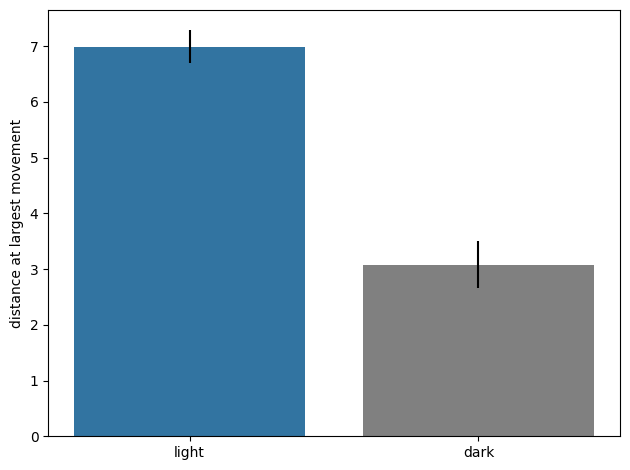

In [110]:
fig,ax = plt.subplots(layout = 'tight')
data = joint[joint.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'task',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at largest movement')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_median = light.distance_at_head_turn_2.median()
light_after= np.nanstd(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

dark = data[data.task == 'oadark']
dark_median = dark.distance_at_head_turn_2.median()
dark_after= np.nanstd(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

ax.errorbar([0,1],[light_median,dark_median] , yerr=[light_after,dark_after], ls='none' ,color="black")


<AxesSubplot: xlabel='task', ylabel='num_turn'>

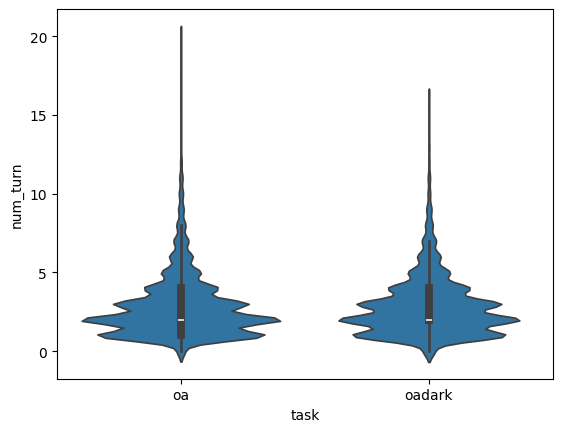

In [87]:
sns.violinplot(data = joint,y = 'num_turn',x = 'task')

<AxesSubplot: xlabel='num_turn', ylabel='Proportion'>

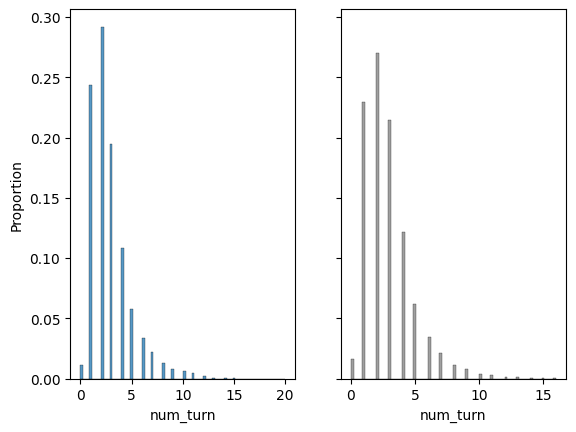

In [85]:
fig,ax = plt.subplots(1,2,sharey=True)
light = joint[(joint.task=='oa') ]
dark = joint[(joint.task=='oadark') ]
sns.histplot(ax = ax[0], data= light,x = 'num_turn',stat='proportion')
sns.histplot(ax = ax[1], data= dark,x = 'num_turn',color = 'grey',stat='proportion')

Text(0.5, 0.98, 'long')

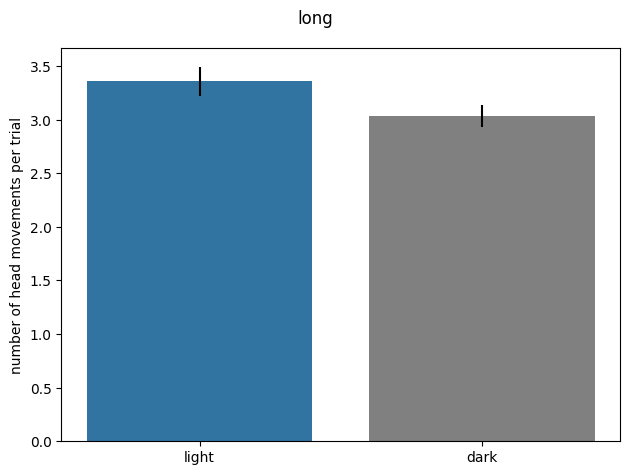

In [112]:
fig,ax = plt.subplots(layout = 'tight')
data = joint[joint.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'time',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.time.mean()
light_after= np.nanstd(light.groupby(['animal']).time.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).time.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.time.mean()
dark_after= np.nanstd(dark.groupby(['animal']).time.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).time.mean().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.suptitle('long')

Text(0.5, 0.98, 'long')

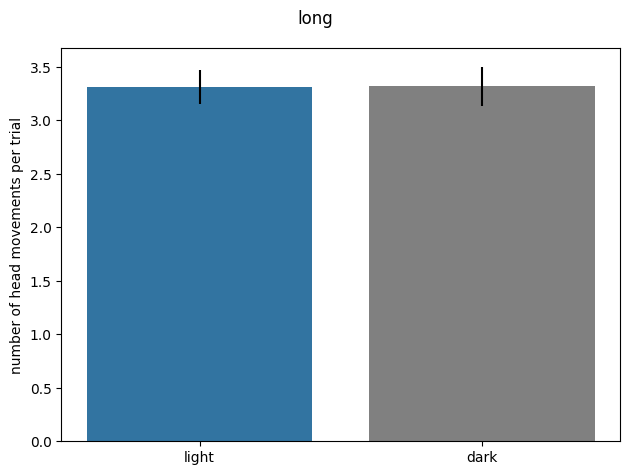

In [75]:
fig,ax = plt.subplots(layout = 'tight')
data = joint[joint.turn_to_obstacle == 'towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'num_turn',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.num_turn.mean()
light_after= np.nanstd(light.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.num_turn.mean()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.mean().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.suptitle('long')


Text(0.5, 0.98, 'short')

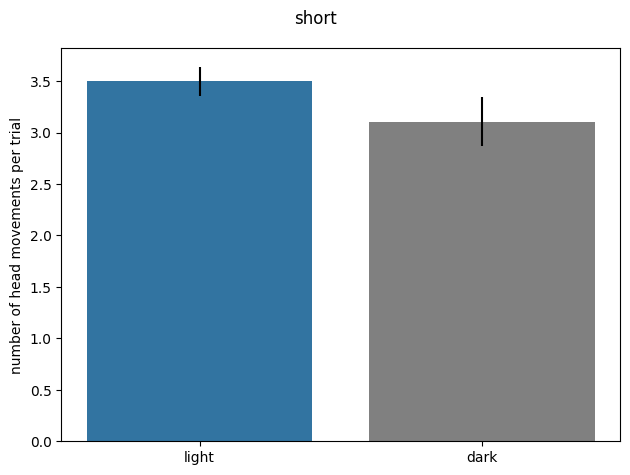

In [32]:
fig,ax = plt.subplots(layout = 'tight')
data = short_nostart

sns.barplot(ax = ax, data = data ,x='task' ,y = 'num_turn',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.num_turn.mean()
light_after= np.nanstd(light.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.num_turn.mean()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.mean().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.suptitle('short')

Text(0.5, 0.98, 'middle')

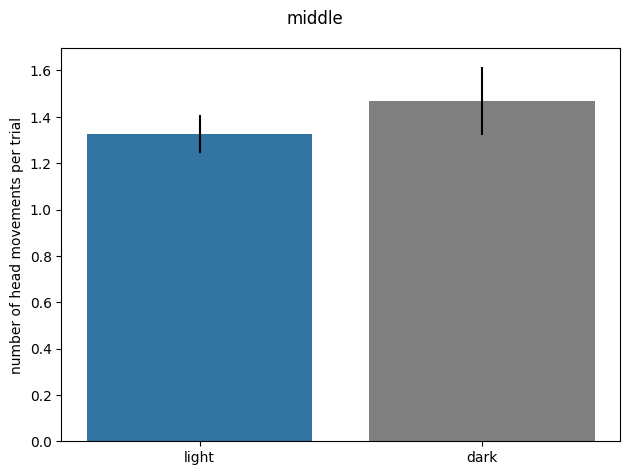

In [71]:
fig,ax = plt.subplots(layout = 'tight')
data = middle_nostart

sns.barplot(ax = ax, data = data ,x='task' ,y = 'num_turn',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head movements per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.num_turn.mean()
light_after= np.nanstd(light.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.num_turn.mean()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.mean().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.suptitle('middle')

In [ ]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=12)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [968]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_oa.h5")
joint = pd.concat([light,dark])

joint = joint.drop(columns=['level_0'])
joint = joint.reset_index()
intial_lateral_error(joint)
avg_lateral_error(joint)
get_head_angle(joint)
angular_velocity_head(joint)
turn_direction(joint)
turn_to_obstacle(joint)
check_trial_for_obstalce_cross_df(joint)
distance_at_head_turn(joint)
zero_out_angle_target_port(joint)

con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
long_con,short_con,middle_con = create_df_by_type(con_df)

In [21]:
light.condition.unique()

array(['control', nan], dtype=object)

In [ ]:
xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
#fig.suptitle('Heading to the Opening')
ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light_medians = []
dark_medians = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        #ax.plot(xnew,task_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                #x = resample(x,20)
                #y = resample(np.flip(np.unique(y)),len(x))
                #y = resample(y,len(x))
                interpolater = interp1d(x,y,bounds_error=False)
                #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)
        
            






        
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
#fig.suptitle('Heading to the Opening')
ax.invert_xaxis()
#ax.invert_yaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.head_corner_angle_velocity_at_head_turn<= -3]

for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['head_corner_angle_velocity'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew*60

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'tab:blue',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'black',alpha = 1)





        
ax.set_ylabel('deg per sec')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:
len(row.ts_nose_x_cm)

In [ ]:
len(row.ts_distance)

In [ ]:
list_columns(long,['distance'])

In [ ]:
test = long.sample(10)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title(str(row.distance_at_head_turn))
    ax[2].set_title(str(row.angle_at_head_turn))
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_angle[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_angle[:int(row.obstacle_ind)].argmin()
    thresh_ind = np.argwhere(row.head_angle[:int(row.obstacle_ind)] == row.head_angle[:int(row.obstacle_ind)][thresh])[0][0]
    ax[1].scatter(thresh_ind,row.head_angle[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_angle[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_angle[:int(row.obstacle_ind)],color = 'tab:orange')

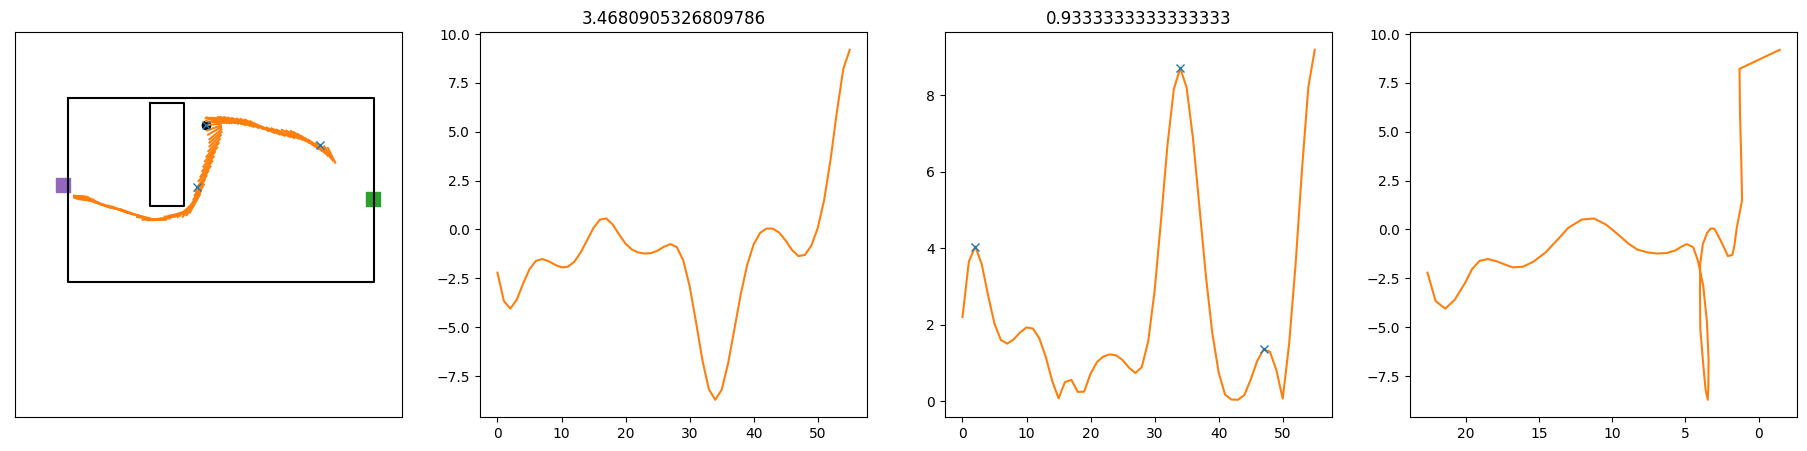

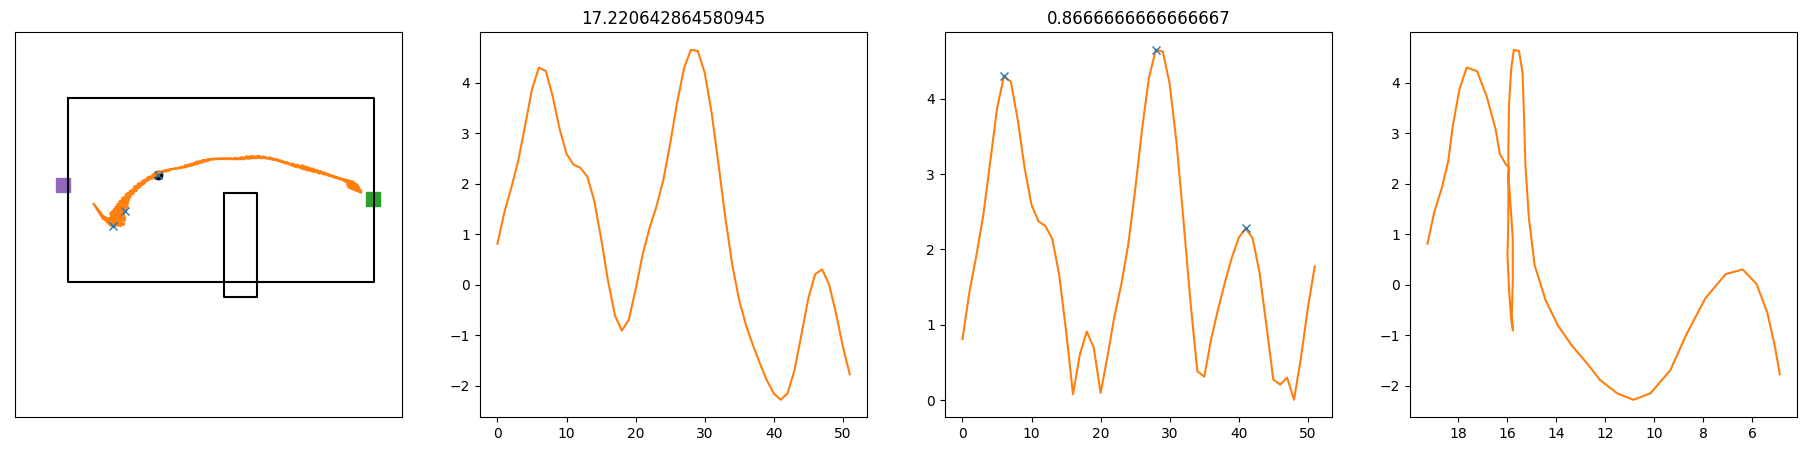

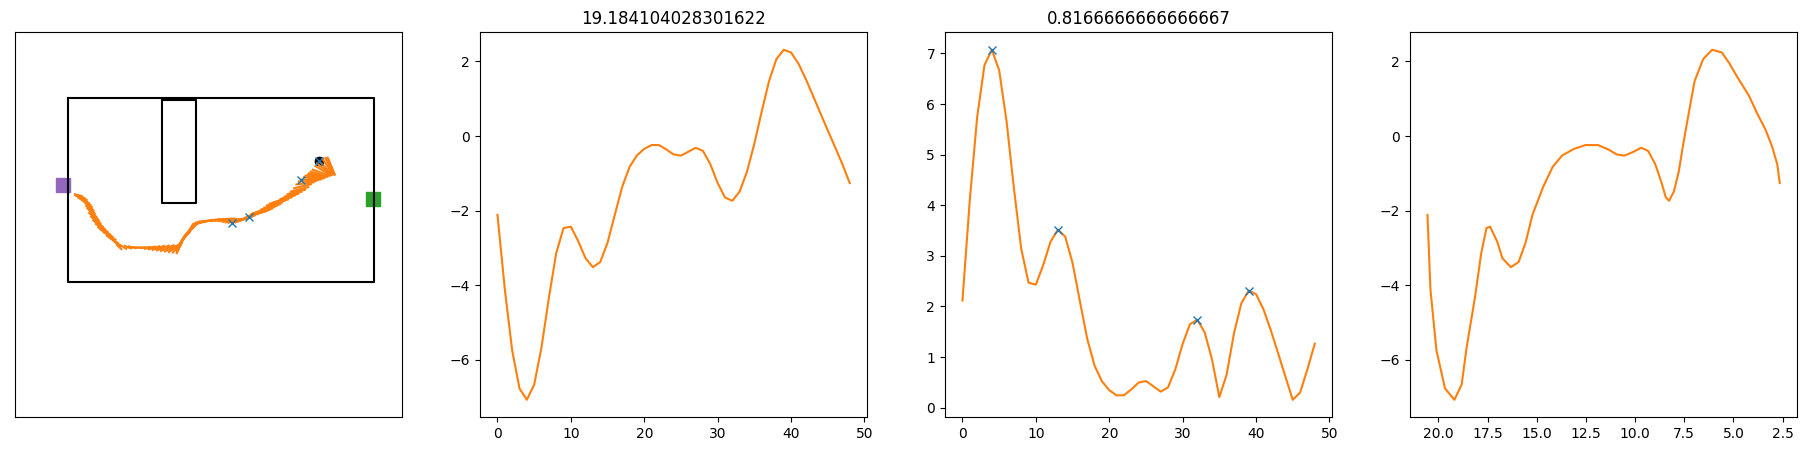

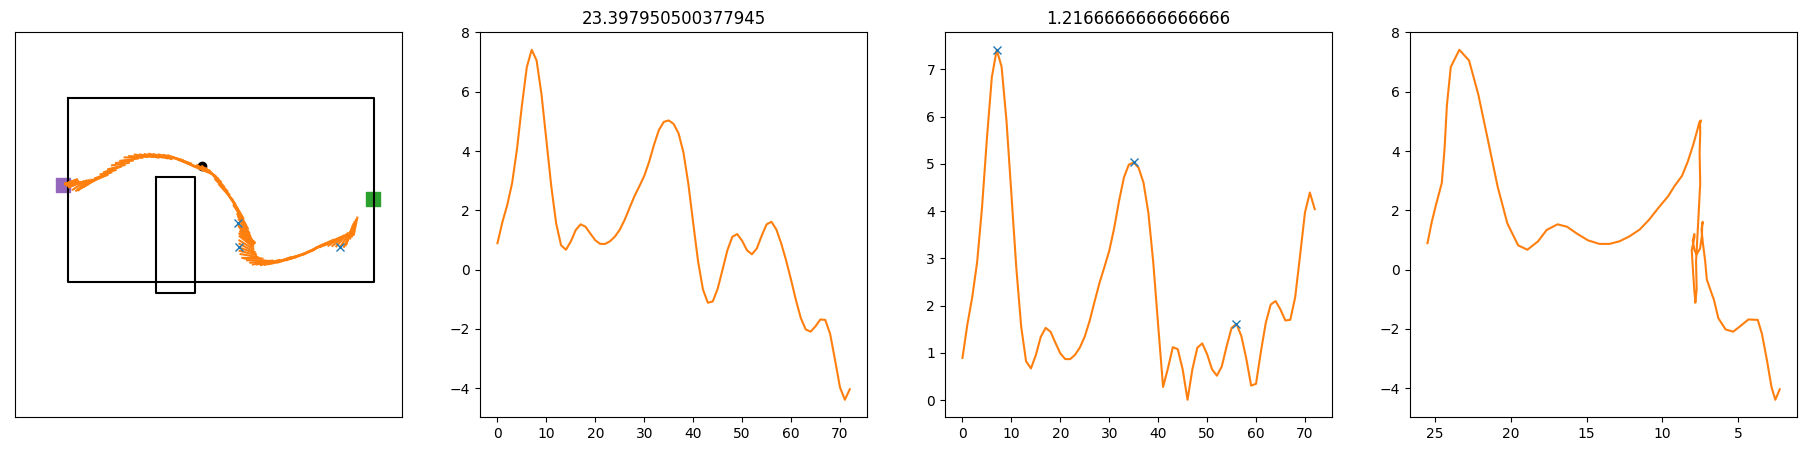

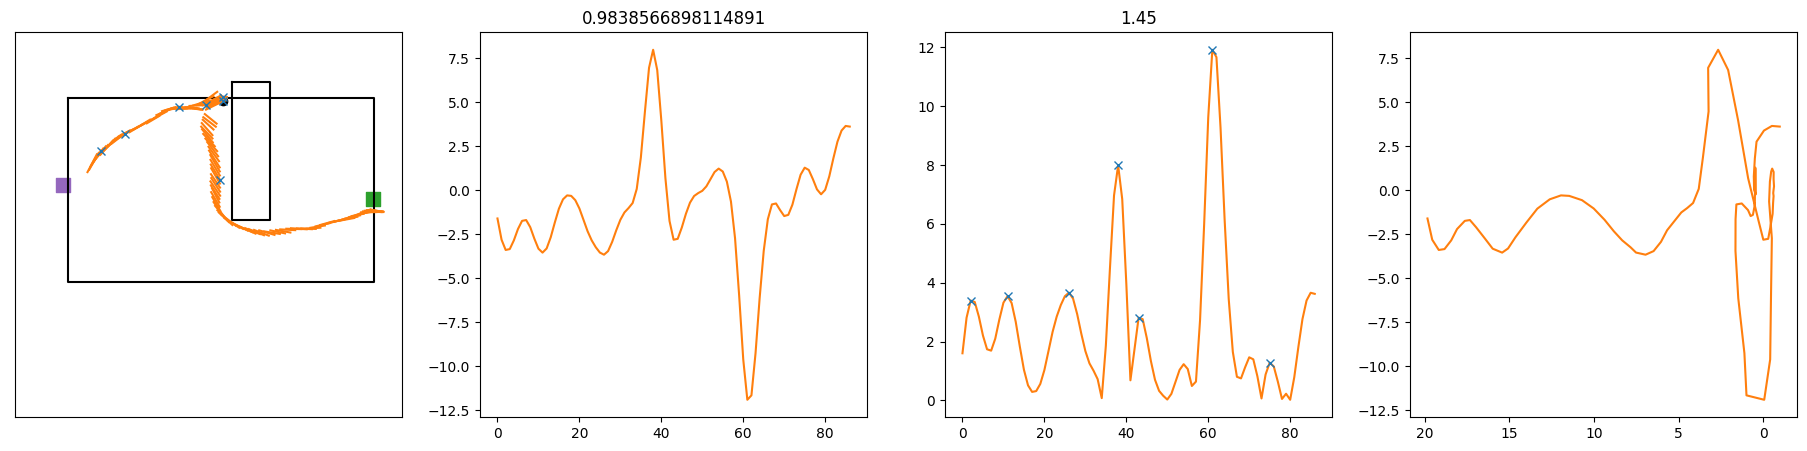

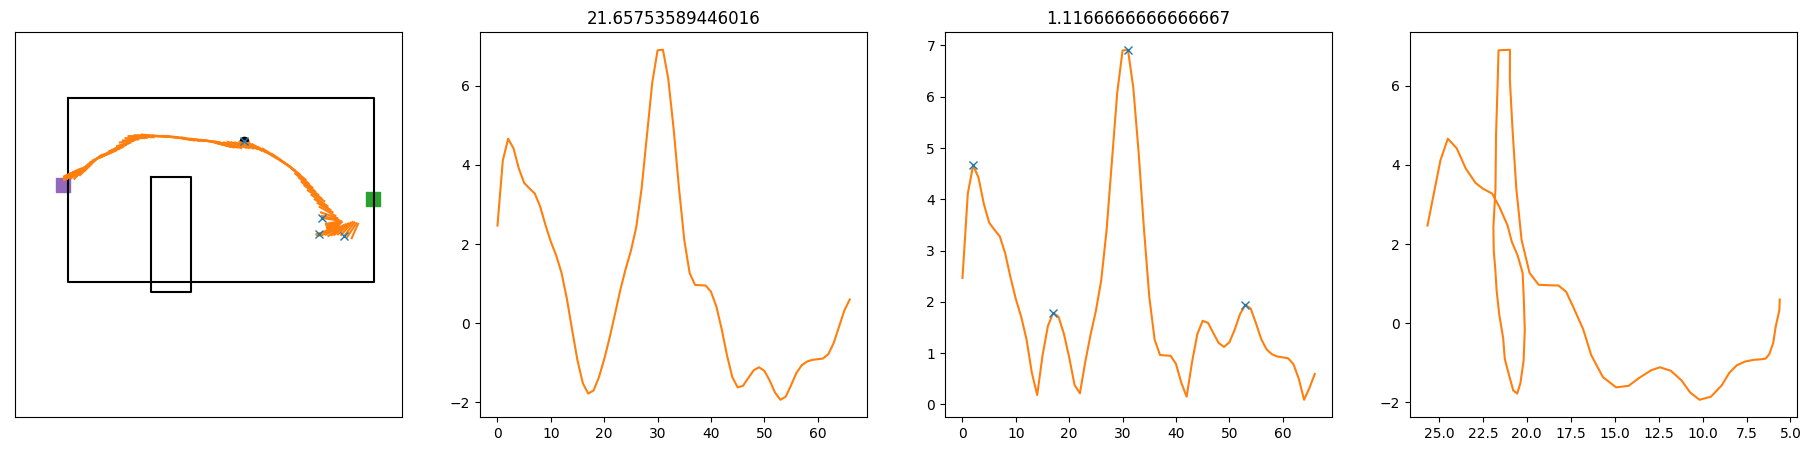

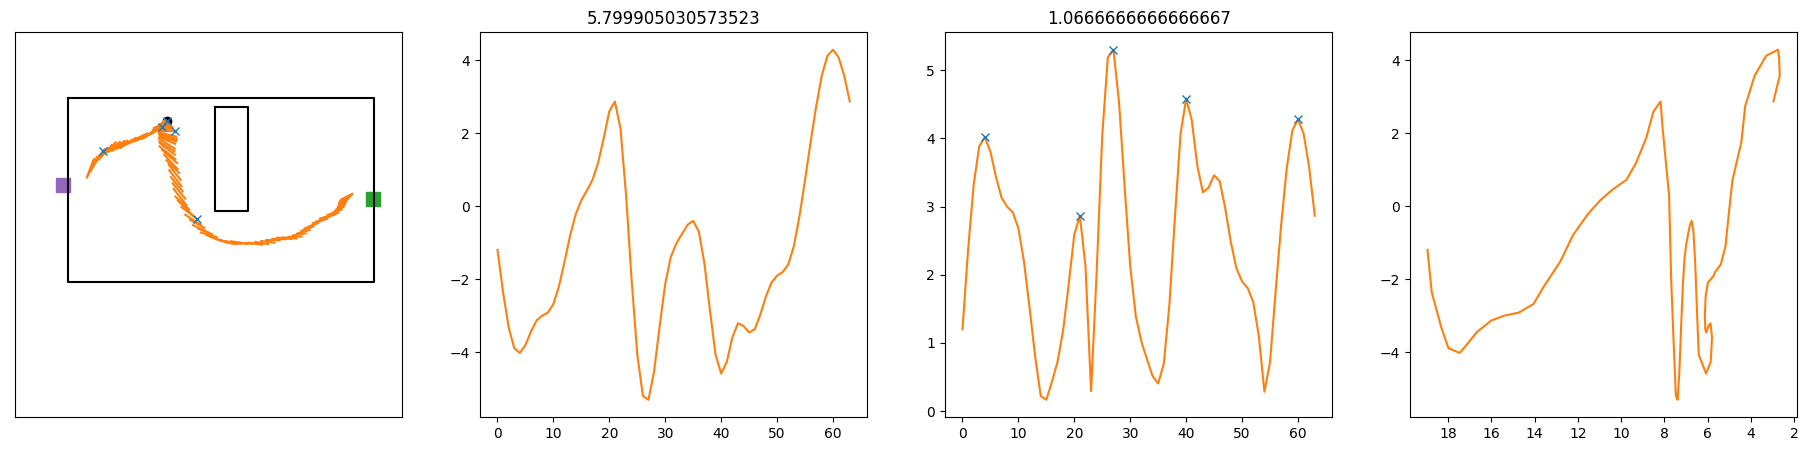

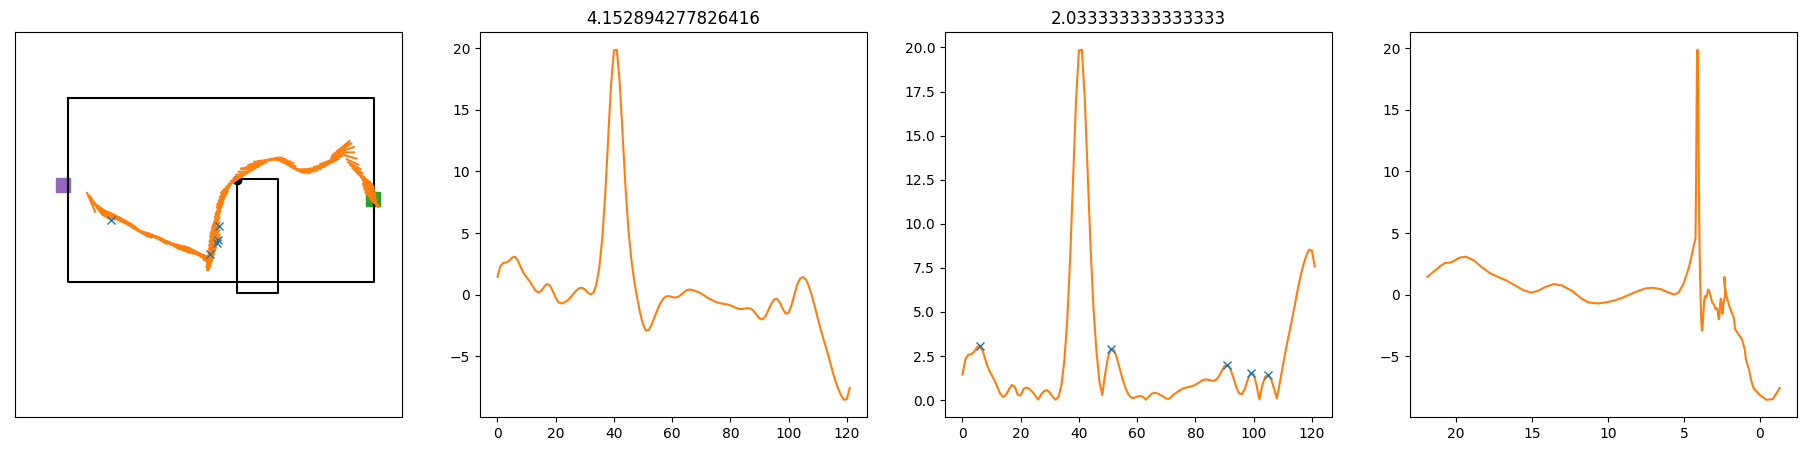

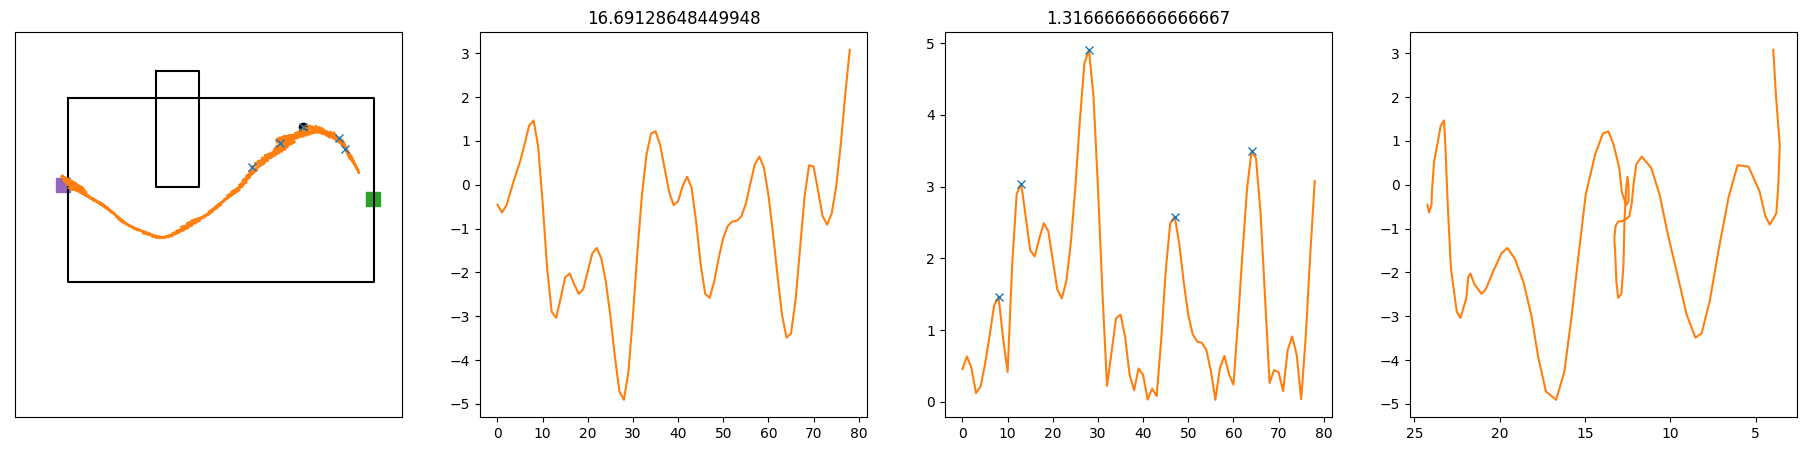

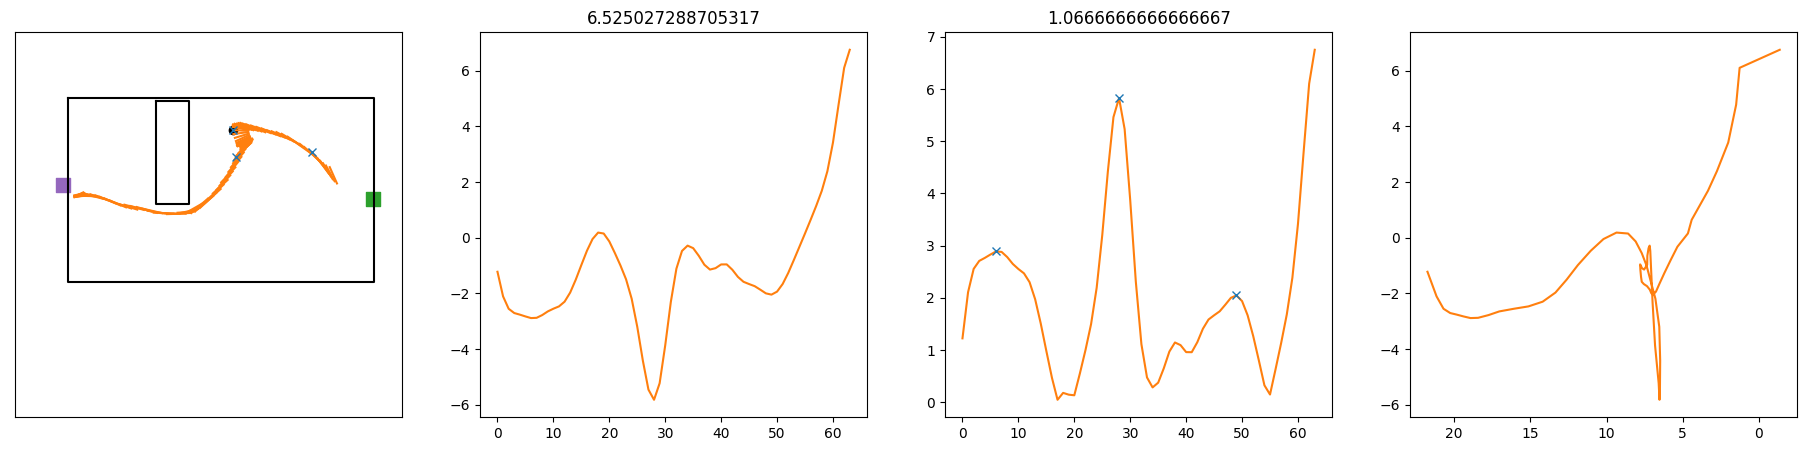

In [33]:
test = long[long.task=='oa'].sample(10)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,4,figsize=(23,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[3].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title(str(row.distance_at_head_turn))
    ax[2].set_title(str(len(row.ts_nose_x_cm[:int(row.obstacle_ind)])/60))
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[3].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_angle_velocity[:int(row.obstacle_ind)].argmin()
    thresh_ind = np.argwhere(row.head_angle_velocity[:int(row.obstacle_ind)] == row.head_angle_velocity[:int(row.obstacle_ind)][thresh])[0][0]
    #ax[1].scatter(thresh_ind,row.head_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    ax[2].plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]),color = 'tab:orange')
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(1,12),prominence=1)
    ax[2].plot(peaks, np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[peaks], "x")
    ax[0].plot(row.ts_nose_x_cm[peaks], row.ts_nose_y_cm[peaks],"x")

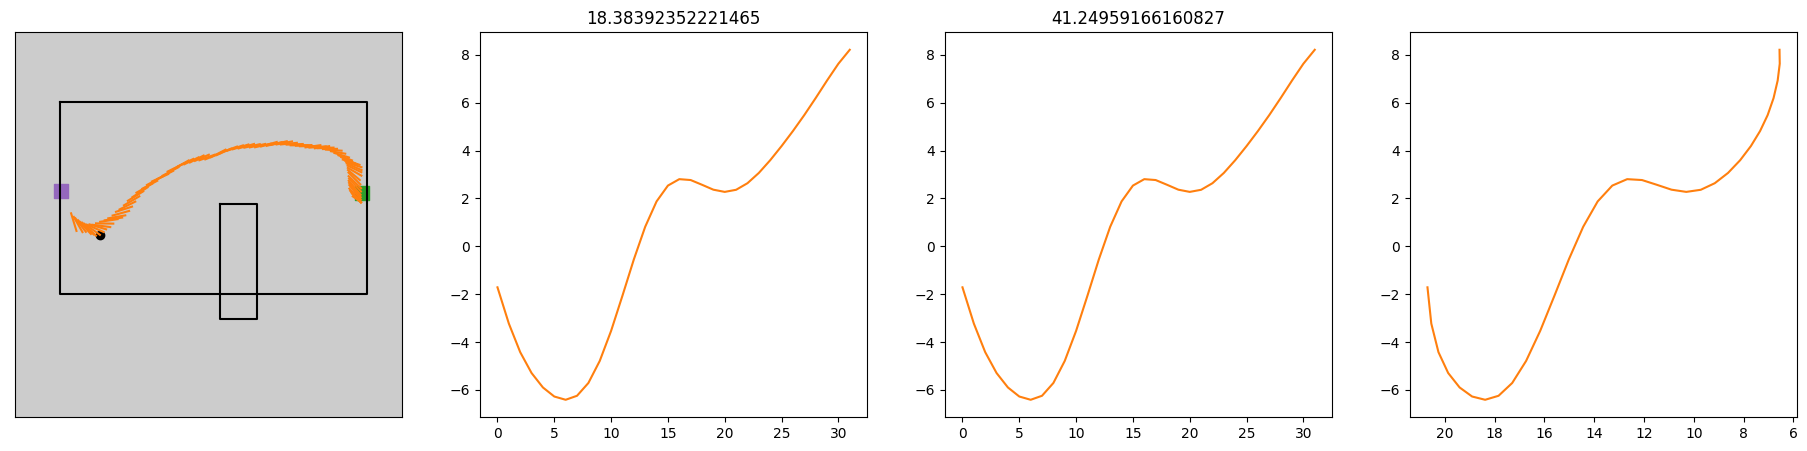

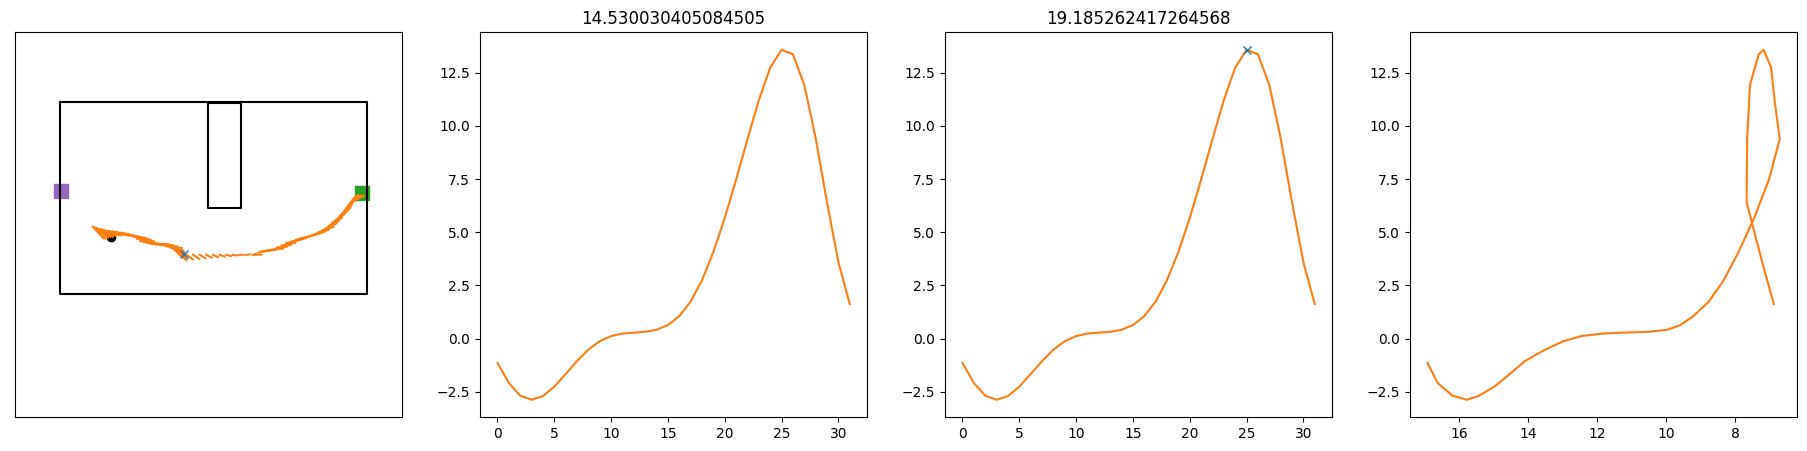

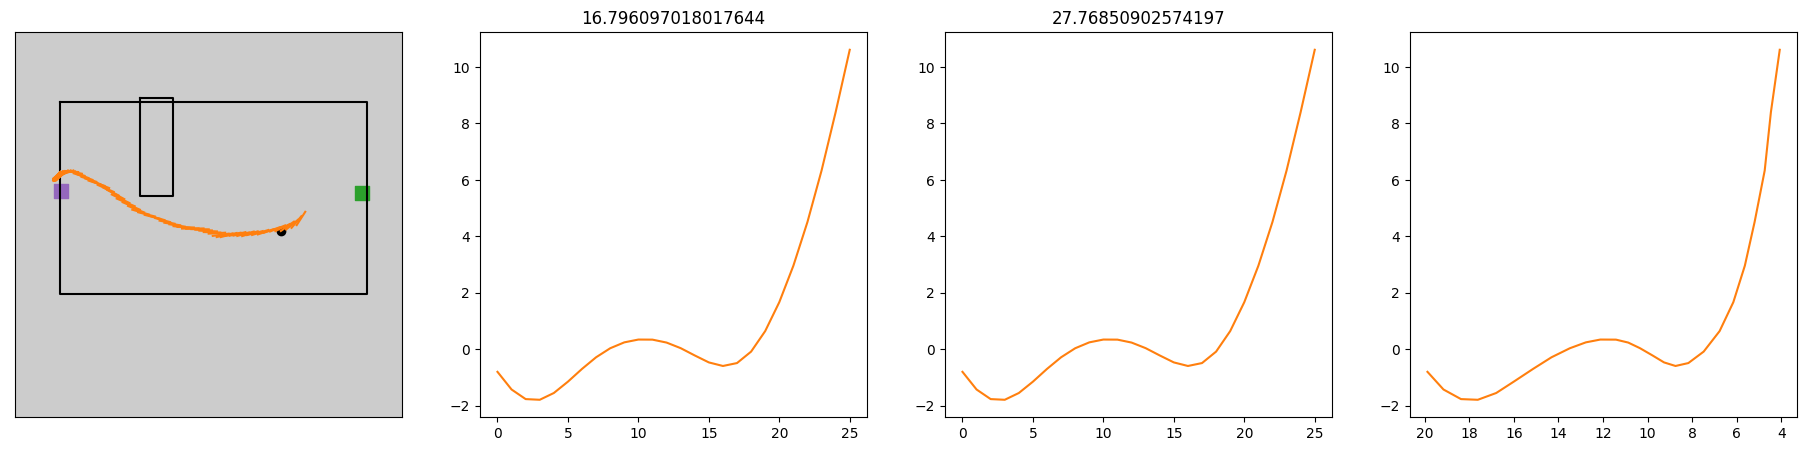

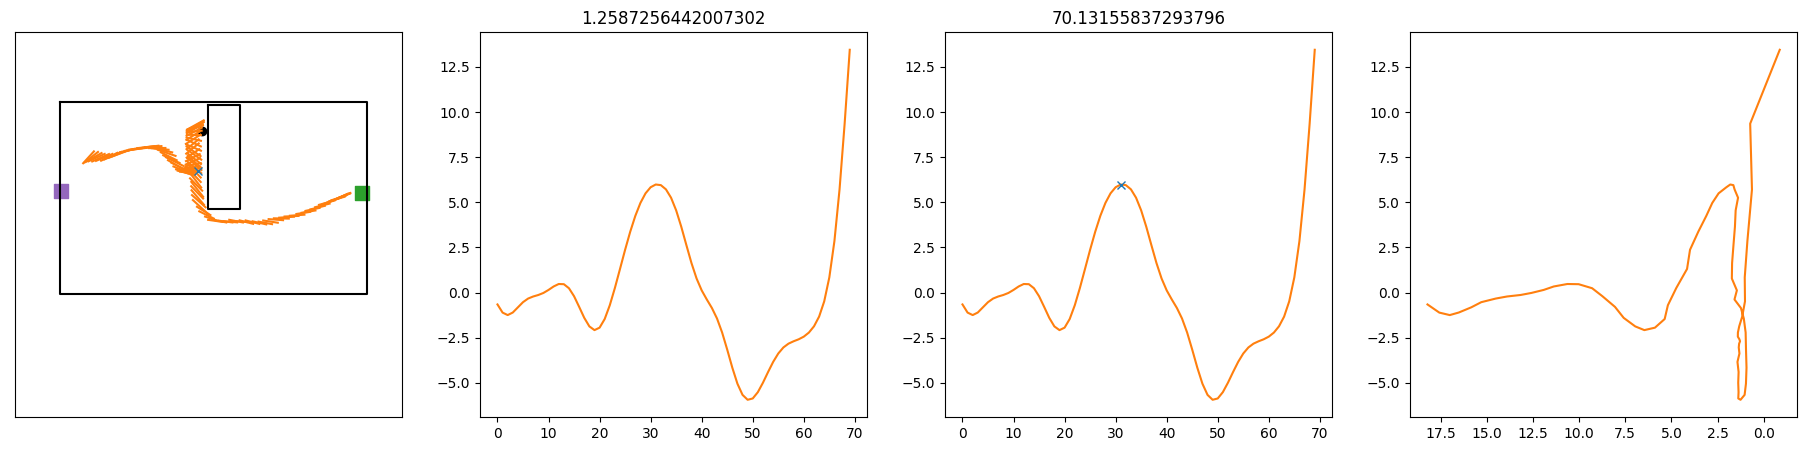

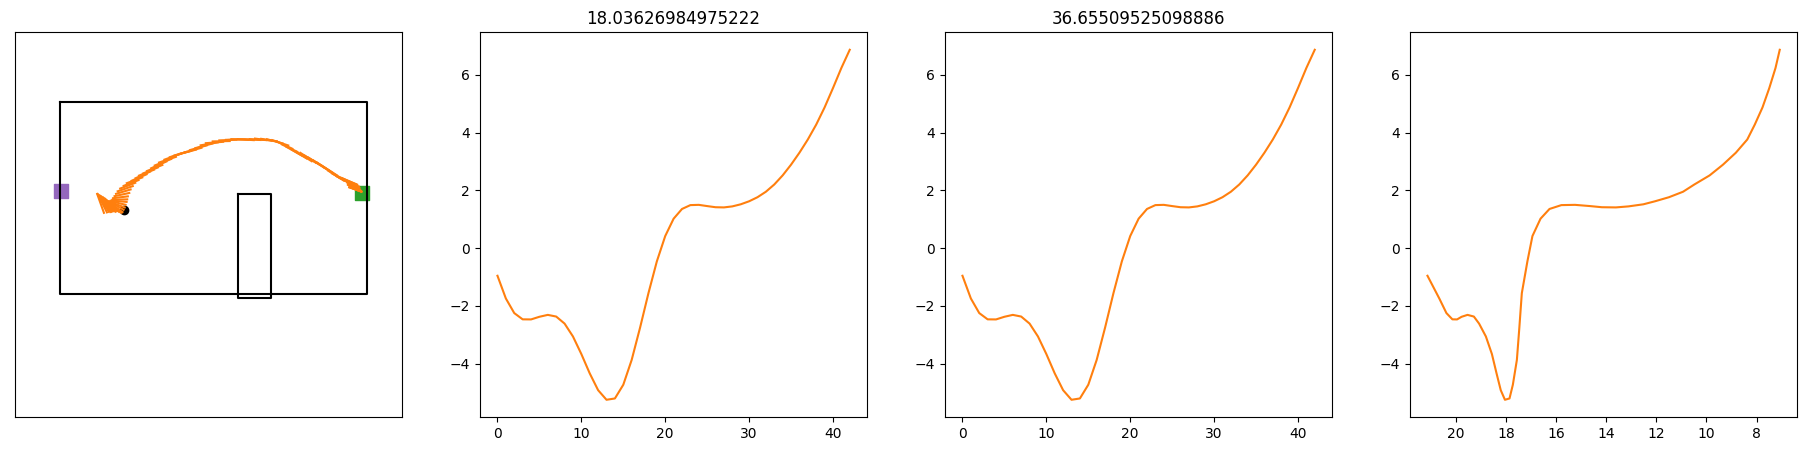

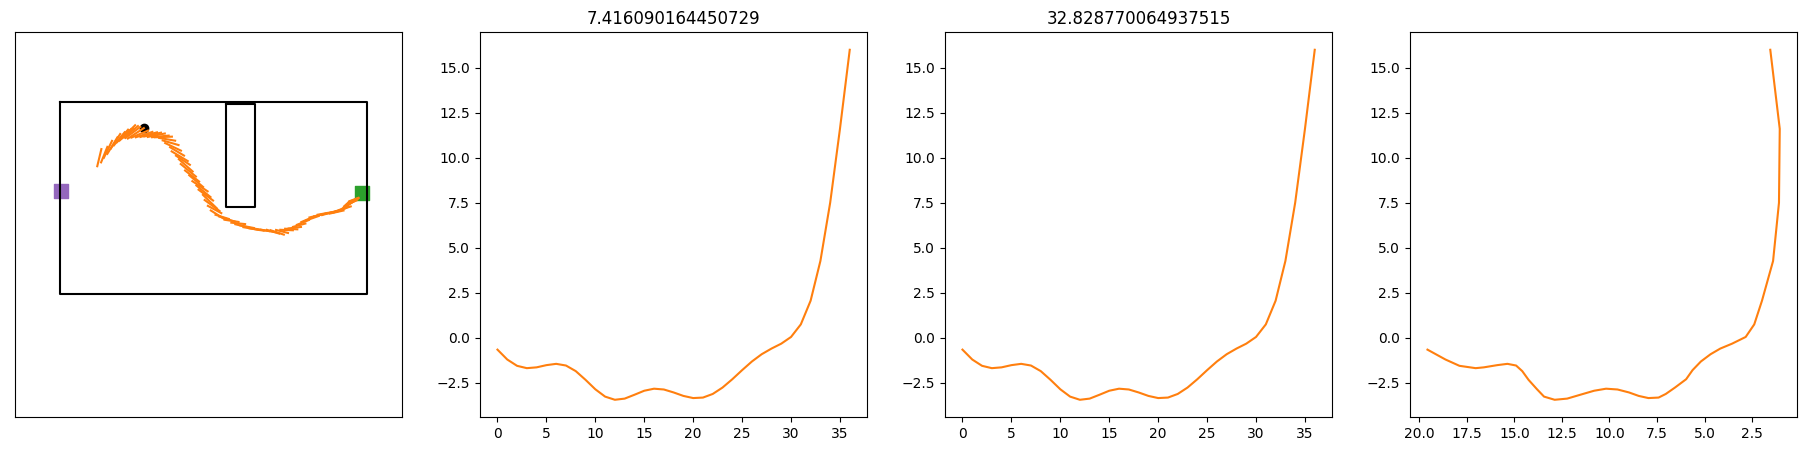

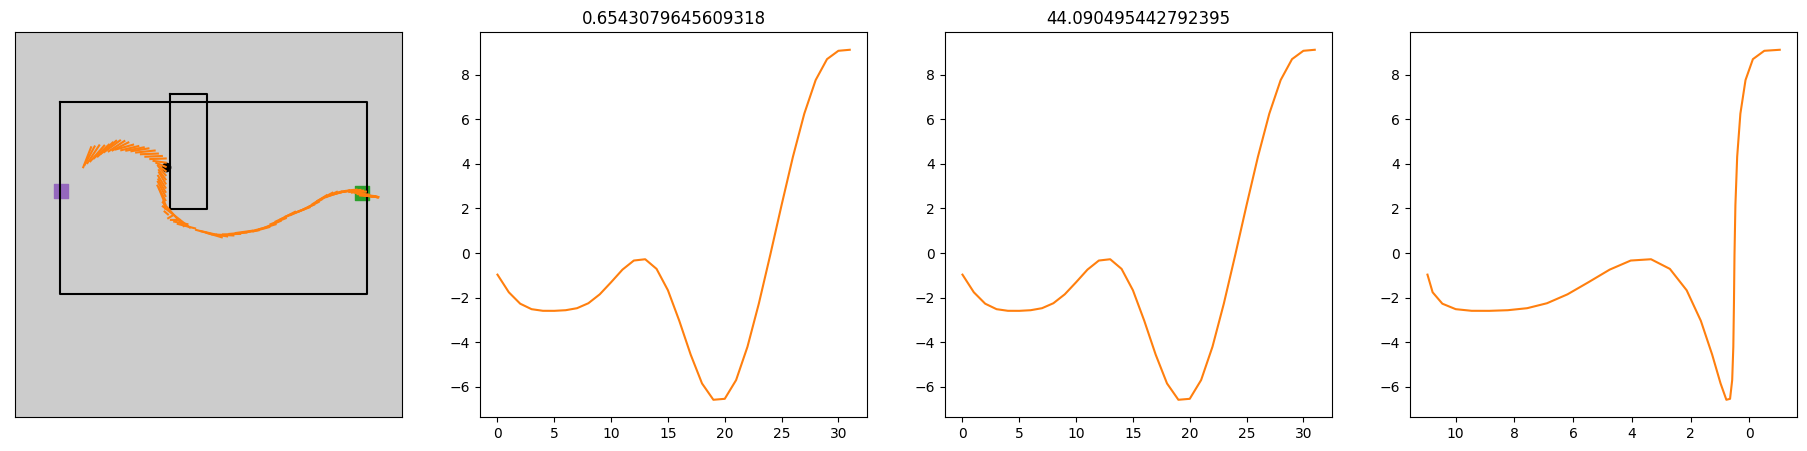

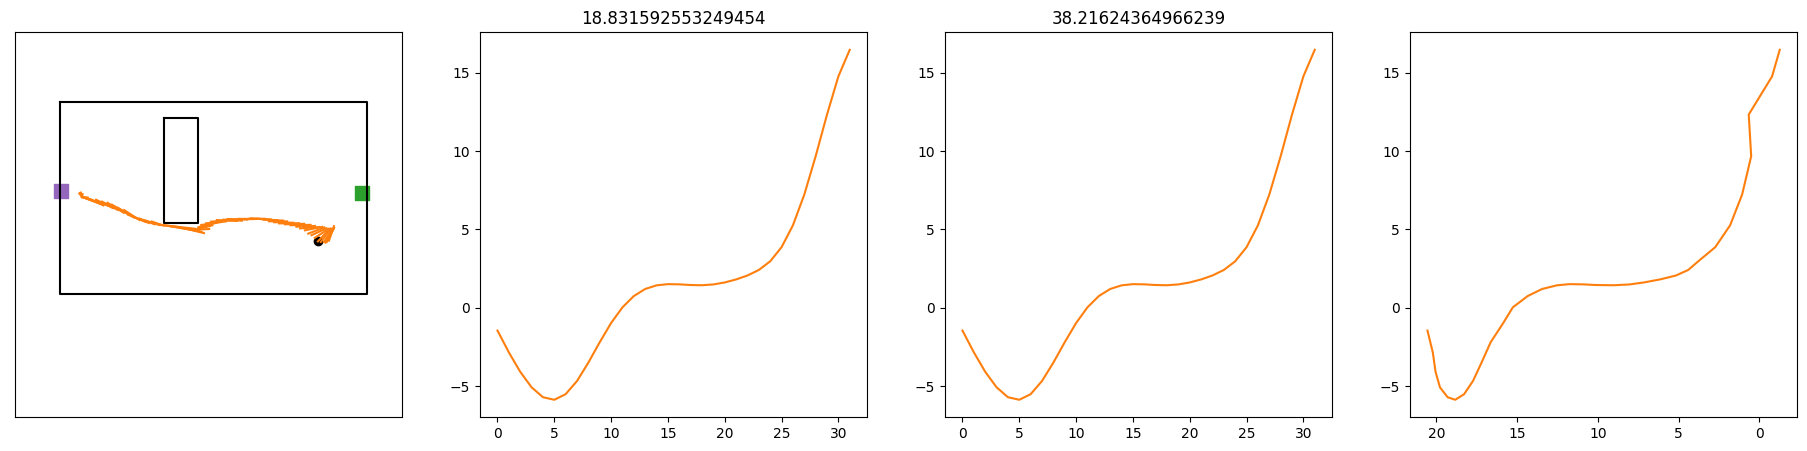

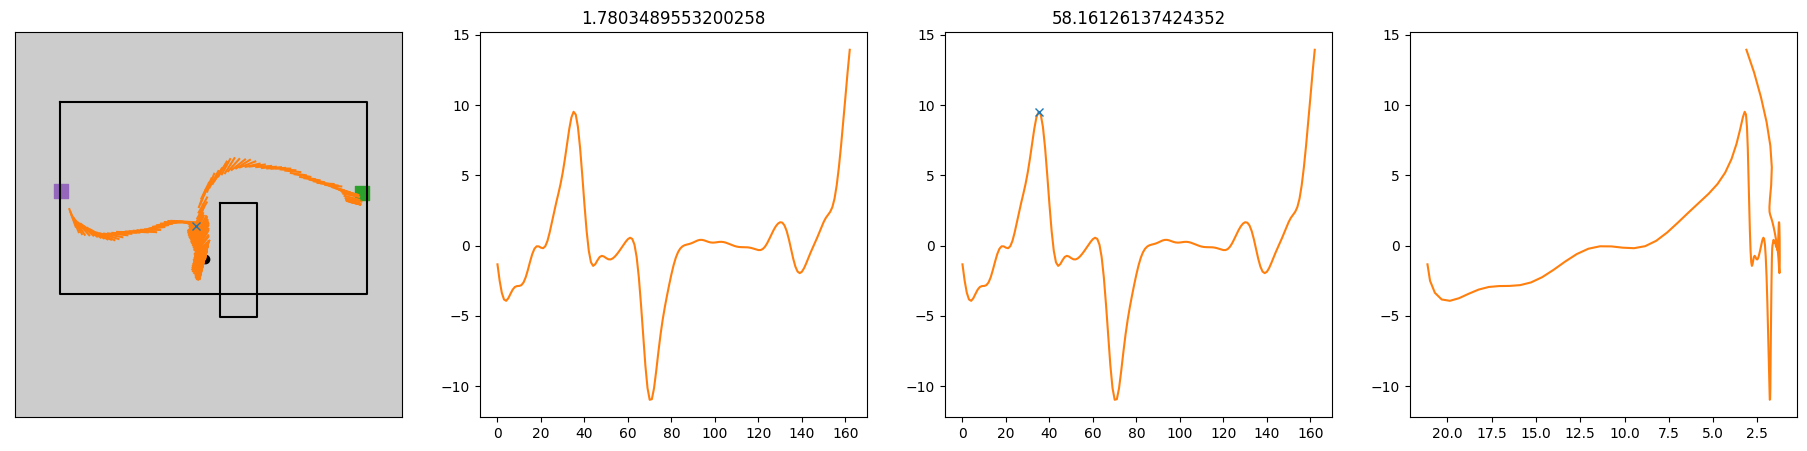

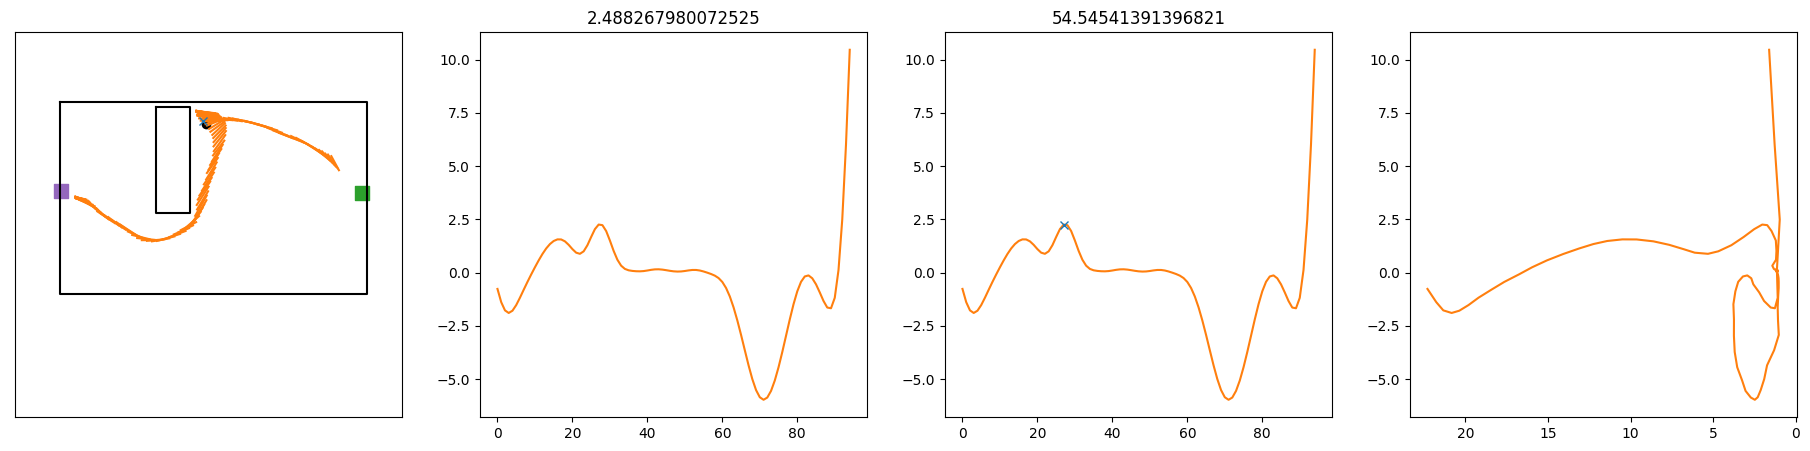

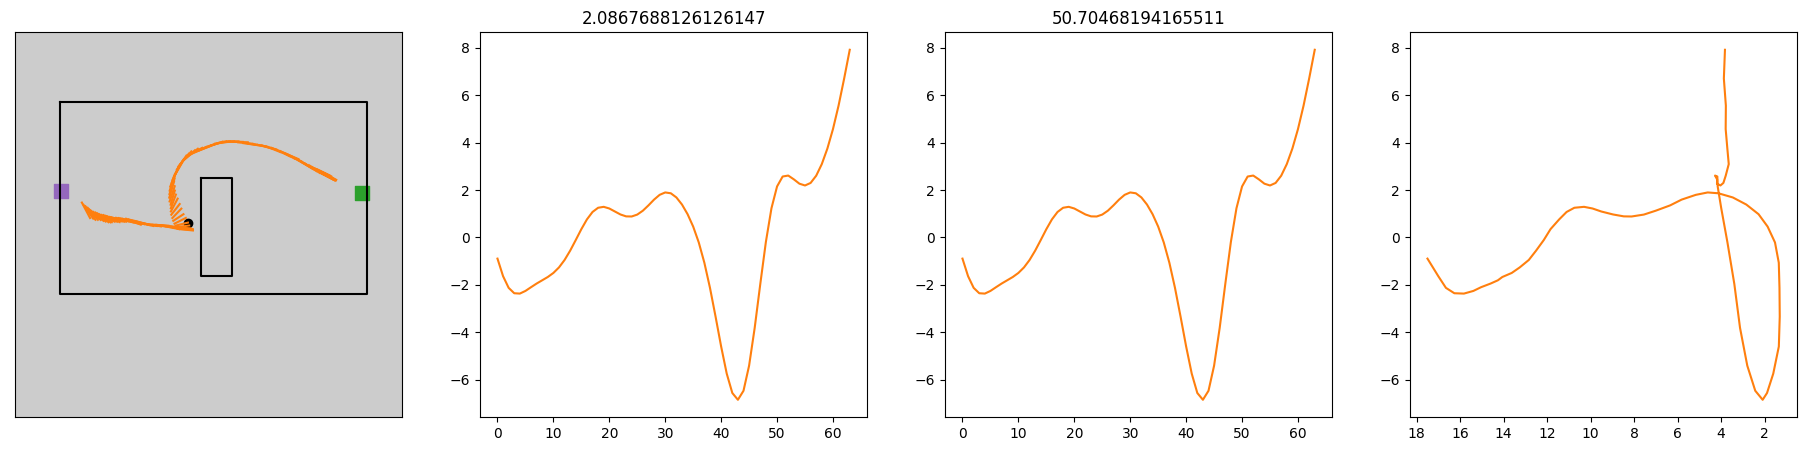

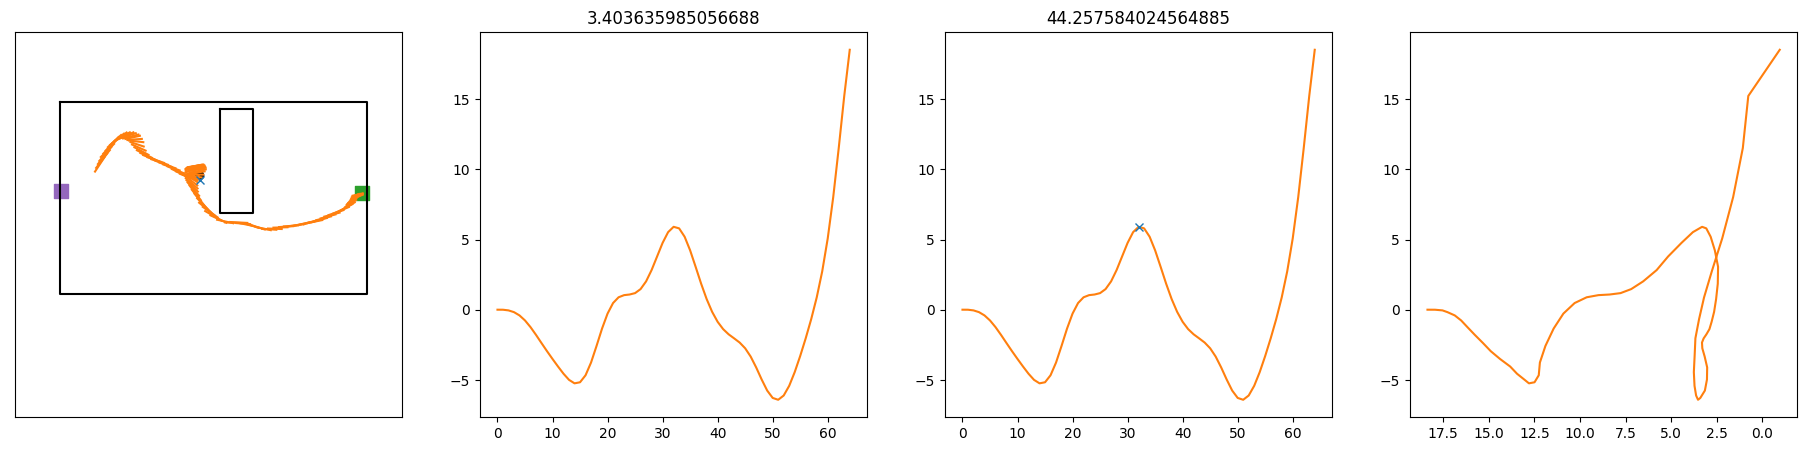

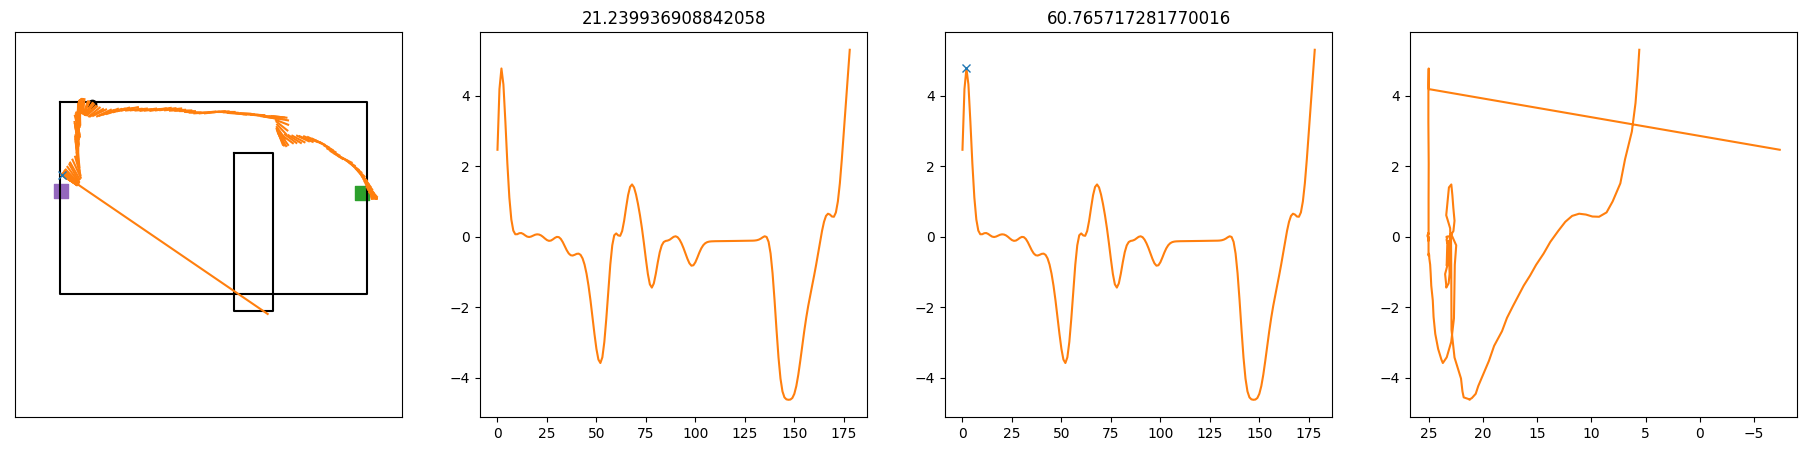

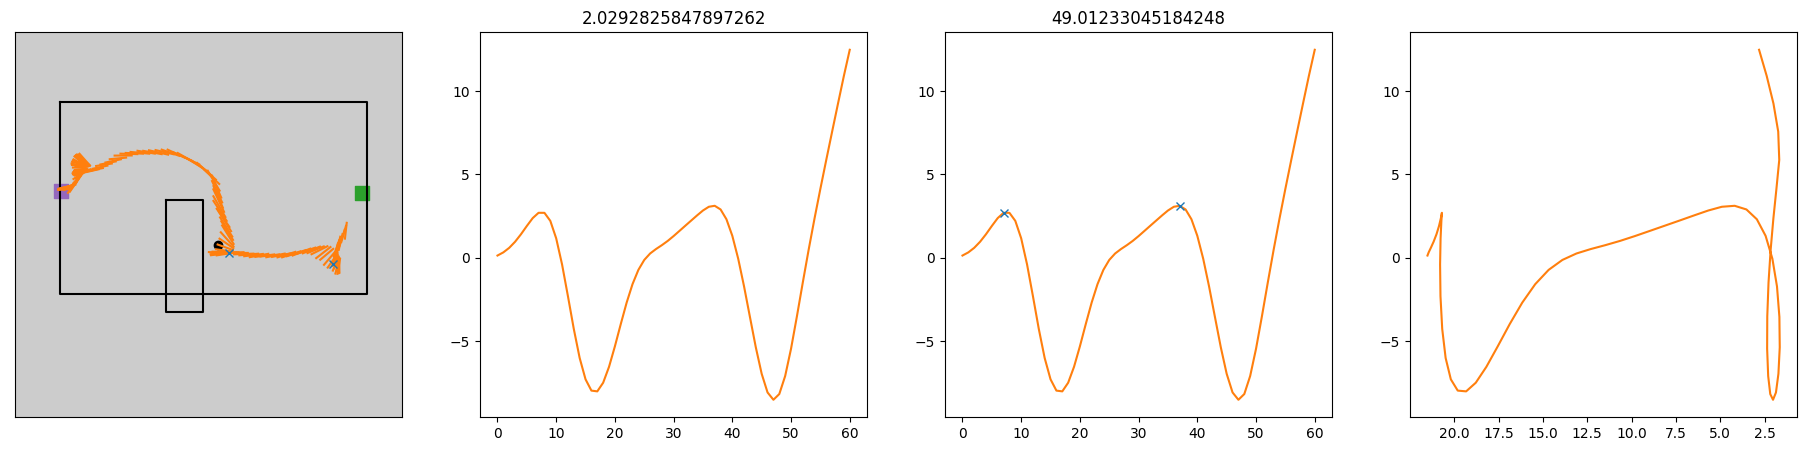

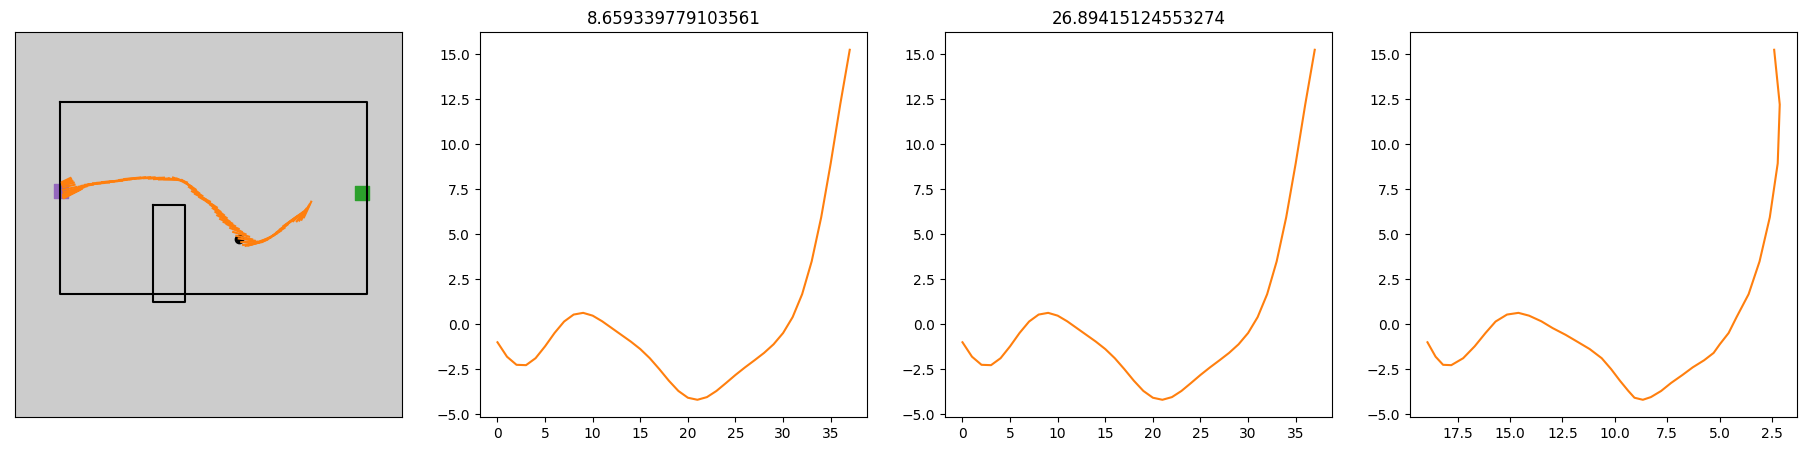

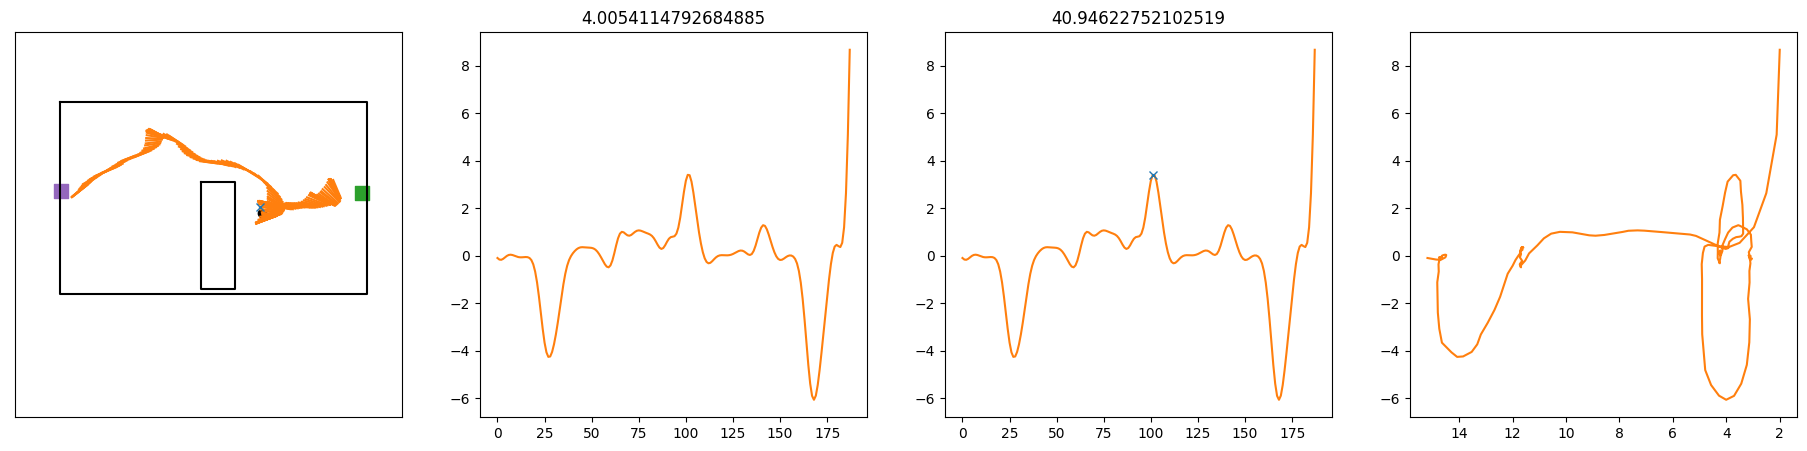

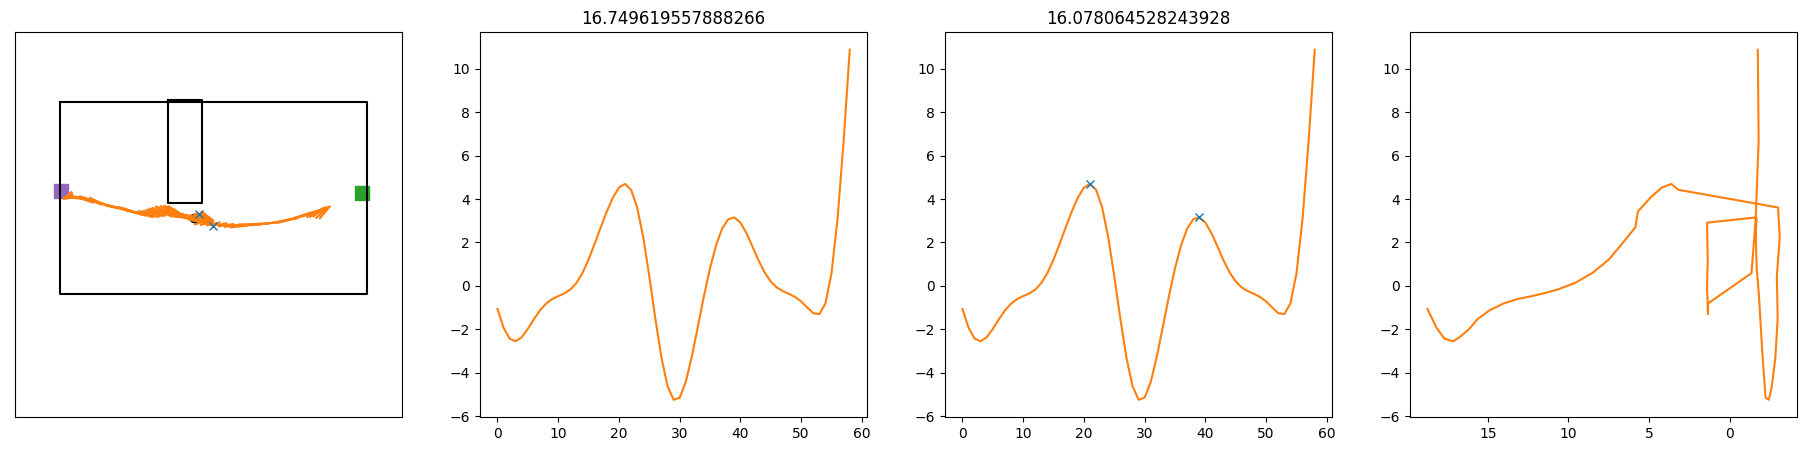

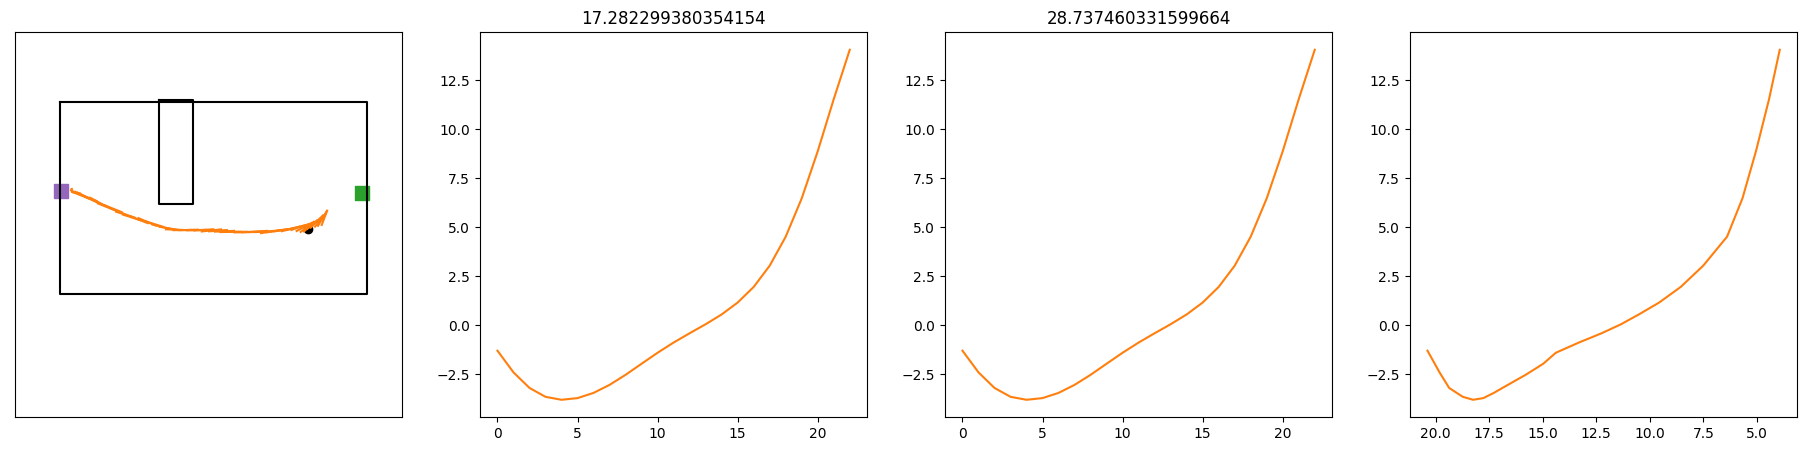

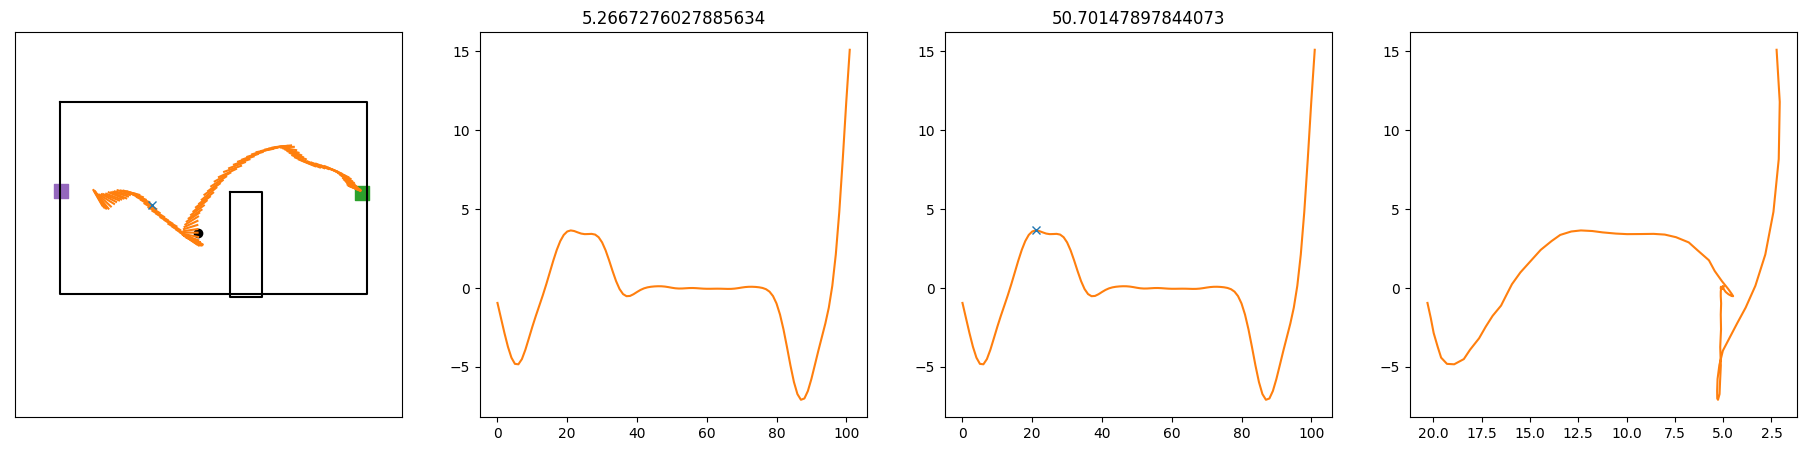

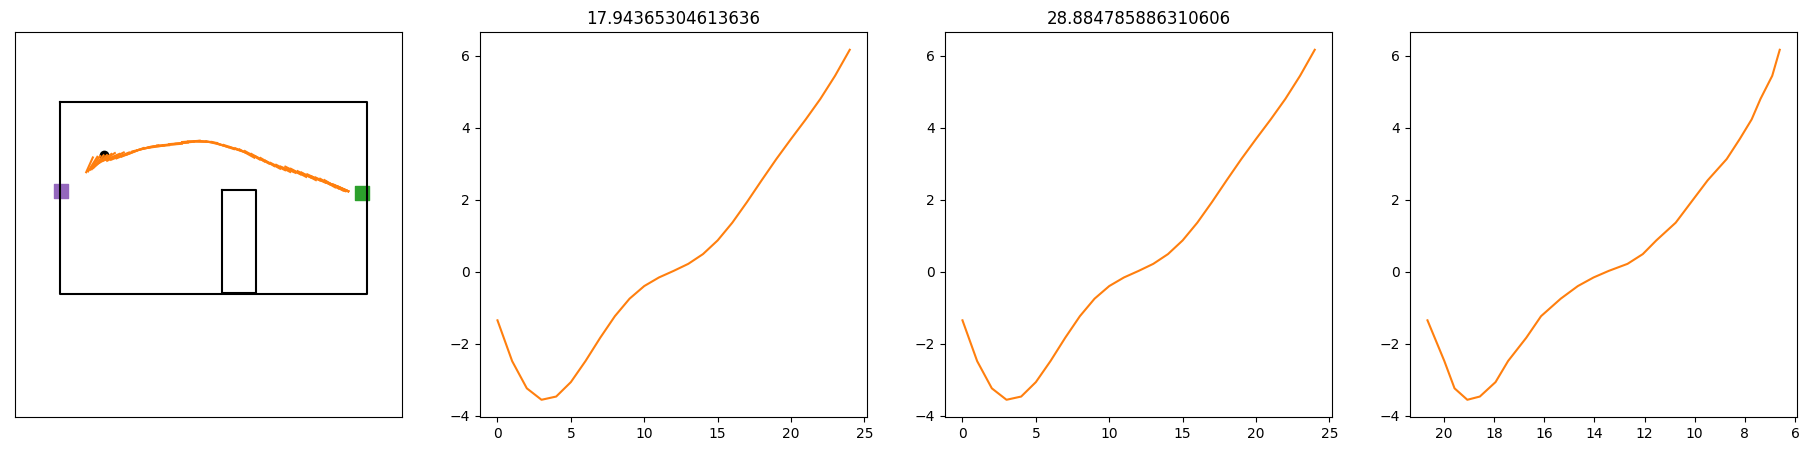

In [76]:
test = long_nostart.sample(20)

for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,4,figsize=(23,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[3].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title(str(row.distance_at_head_turn))
    ax[2].set_title(str(row.angle_at_head_turn))
   
    #ax[1].set_ylim(-12,2)

    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[3].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_corner_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    thresh_ind = np.argwhere(row.head_corner_angle_velocity[:int(row.obstacle_ind)] == row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh])[0][0]
    #ax[1].scatter(thresh_ind,row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    #ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_corner_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    ax[2].plot(row.head_corner_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    peaks, prop = find_peaks(row.head_corner_angle_velocity[:int(row.obstacle_ind)], width=1,height=(2),prominence=1)
    ax[2].plot(peaks, row.head_corner_angle_velocity[:int(row.obstacle_ind)][peaks], "x")
    ax[0].plot(row.ts_nose_x_cm[peaks], row.ts_nose_y_cm[peaks],"x")
    
    

In [ ]:
head_turns =  []
test = long[long.task=='oadark'].sample(5)
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    plt.plot(np.linspace(-1,1,len(turn)),turn)
plt.ylim(0,20)
plt.xlim(-15,15)


In [ ]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_distances =  []
light = middle[(middle.task=='oa') ]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(2,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        head_turn_distances.append(distance)
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = middle[(middle.task=='oadark') ]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(2,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        head_turn_distances.append(distance)
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')
ax[0].set_xlabel('distance of headturn (cm)')
ax[1].set_xlabel('distance of headturn (cm)')

Text(0.5, 0, 'distance of headturn (cm)')

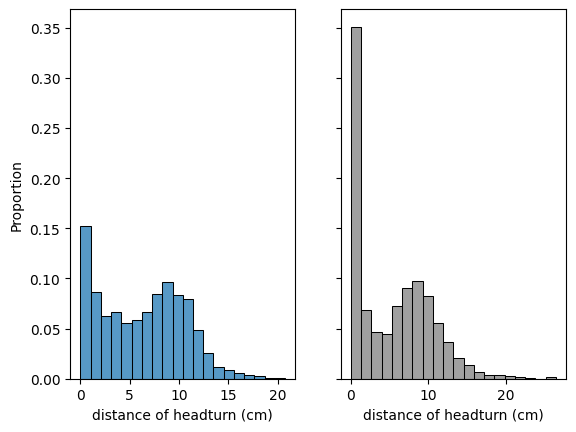

In [115]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_distances =  []
light = short_nostart[(short_nostart.task=='oa') ]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(2,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance >= 0: 
            head_turn_distances.append(distance)
        else:
            continue
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = short_nostart[(short_nostart.task=='oadark') ]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(2,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance >= 0: 
            head_turn_distances.append(distance)
        else:
            continue
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')
ax[0].set_xlabel('distance of headturn (cm)')
ax[1].set_xlabel('distance of headturn (cm)')

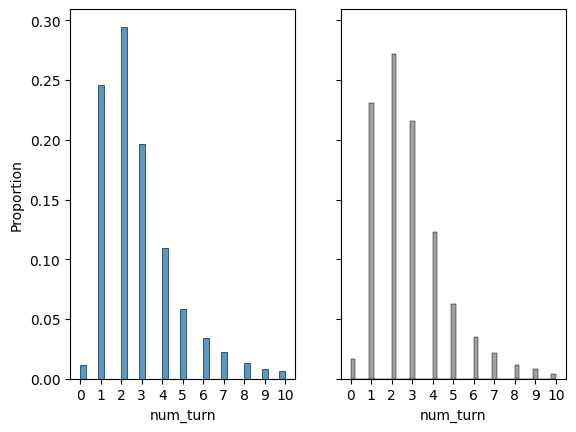

In [117]:
fig,ax  = plt.subplots(1,2,sharey=True)
light = joint[(joint.task=='oa') ]
dark = joint[(joint.task=='oadark') ]
sns.histplot (ax =ax[0], data = light[light.num_turn <= 10]  ,x = 'num_turn',stat='proportion') 
sns.histplot (ax =ax[1], data = dark[dark.num_turn <= 10]   ,x = 'num_turn',stat='proportion',color ='grey') 
ax[0].set_xticks([0,1,2,3,4,5,6,7,8,9,10])
ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9,10])

TypeError: object of type 'numpy.float64' has no len()

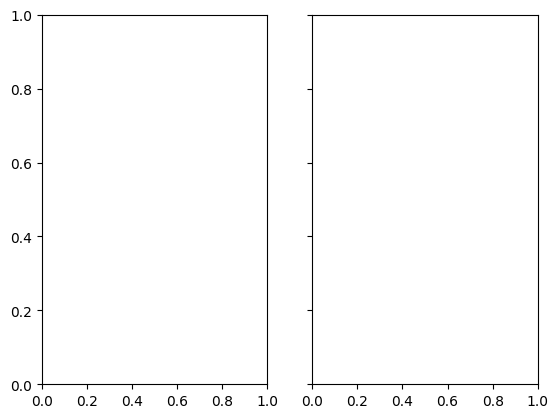

In [15]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_heights =  []
light = long_nostart[(long_nostart.task=='oa') ]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,12),prominence=1)
    inds = prop['peak_heights']
    for i,v in enumerate(inds):
        height = v
        if height<=0:
            continue
        else:
            head_turn_heights.append(height)
#ax.hist(head_turn_heights,bins=20)
head_turn_heights = np.asarray(head_turn_heights)
sns.barplot(ax= ax[0],data = head_turn_heights.mean())

head_turn_heights =  []
dark = long_nostart[(long_nostart.task=='oadark') ]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,12),prominence=1)
    inds = prop['peak_heights']
    for i,v in enumerate(inds):
        height = v
        if height<=0:
            continue
        else:
            head_turn_heights.append(height)
head_turn_heights = np.asarray(head_turn_heights)
sns.barplot(ax= ax[1],data = head_turn_heights.mean())
#ax[0].set_ylim(0,.25)
fig.suptitle('long')
ax[0].set_xlabel('height of headturn (cm)')
ax[1].set_xlabel('height of headturn (cm)')

In [16]:
head_turn_heights.mean()

5.526442037509441

In [14]:
head_turn_heights.mean()

6.019236241230062

In [12]:
sns.barplot(data = head_turn_heights, x =[0])

TypeError: Data source must be a DataFrame or Mapping, not <class 'numpy.ndarray'>.

Text(0.5, 0, 'distance of headturn (cm)')

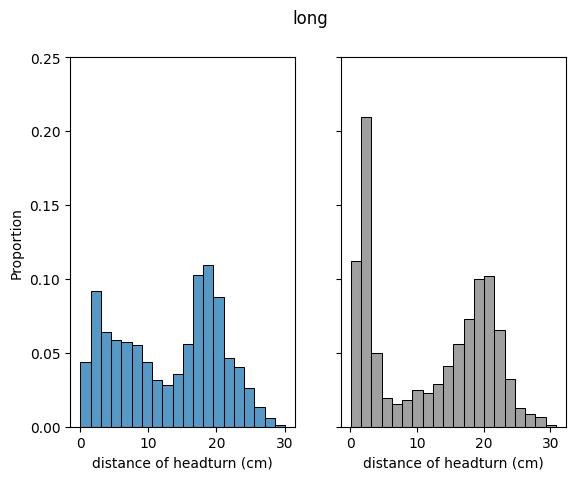

In [76]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_distances =  []
light = long_nostart[(long_nostart.task=='oa') ]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = long_nostart[(long_nostart.task=='oadark') ]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')
ax[0].set_ylim(0,.25)
fig.suptitle('long')
ax[0].set_xlabel('distance of headturn (cm)')
ax[1].set_xlabel('distance of headturn (cm)')

Text(0.5, 0, 'distance of headturn (cm)')

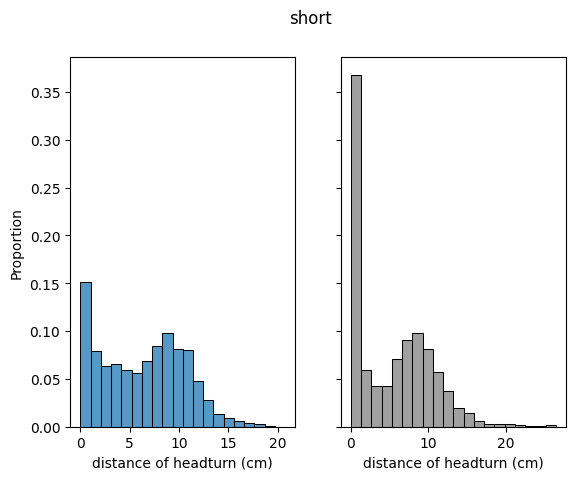

In [77]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_distances =  []
light = short_nostart[(short_nostart.task=='oa') ]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = short_nostart[(short_nostart.task=='oadark') ]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')

#ax[0].set_ylim(0,.25)
fig.suptitle('short')
ax[0].set_xlabel('distance of headturn (cm)')
ax[1].set_xlabel('distance of headturn (cm)')


Text(0.5, 0, 'distance of headturn (cm)')

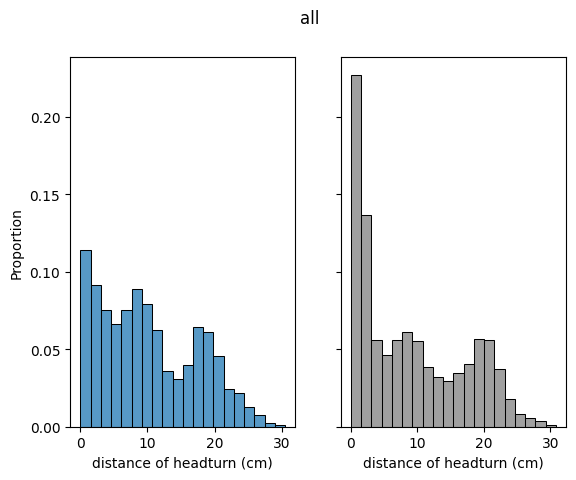

In [50]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_distances =  []
light = joint[(joint.task=='oa') ]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = joint[(joint.task=='oadark') ]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')

#ax[0].set_ylim(0,.25)
fig.suptitle('all')

ax[0].set_xlabel('distance of headturn (cm)')
ax[1].set_xlabel('distance of headturn (cm)')


Text(0.5, 0.98, 'short')

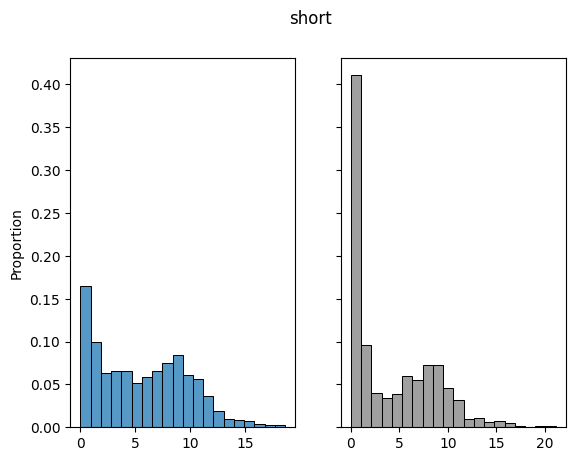

In [42]:
fig,ax = plt.subplots(1,2,sharey=True)
head_turn_distances =  []
light = short_nostart[(short_nostart.task=='oa') & (short_nostart.turn_to_obstacle == 'towards')]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = short_nostart[(short_nostart.task=='oadark') & (short_nostart.turn_to_obstacle == 'towards')]
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance<=0:
            continue
        else:
            head_turn_distances.append(distance)
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')

#ax[0].set_ylim(0,.25)
fig.suptitle('short')


(0.0, 0.3)

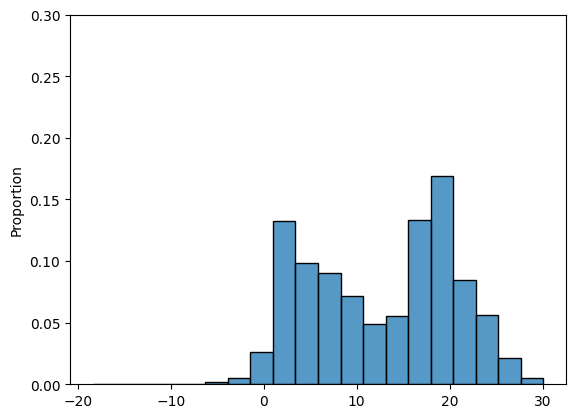

In [316]:
fig,ax = plt.subplots(1)
head_turn_distances =  []
test = long_nostart[long_nostart.task=='oa']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        head_turn_distances.append(distance)
#ax.hist(head_turn_distances,bins=20)
sns.histplot(data = head_turn_distances,bins=20,stat='proportion')
plt.ylim(0,.3)

(0.0, 0.7)

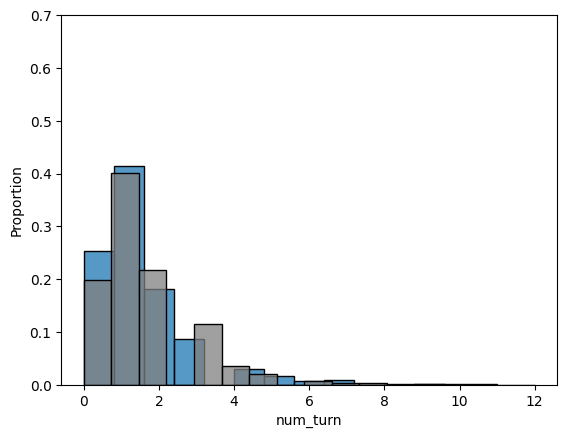

In [324]:
test = middle[middle.task=='oa']
sns.histplot(test,x='num_turn',stat='proportion',color='tab:blue',bins=15)
test = middle[middle.task=='oadark']
sns.histplot(test,x='num_turn',stat='proportion',color='grey',bins=15)
plt.ylim(0,.7)

(0.0, 0.5)

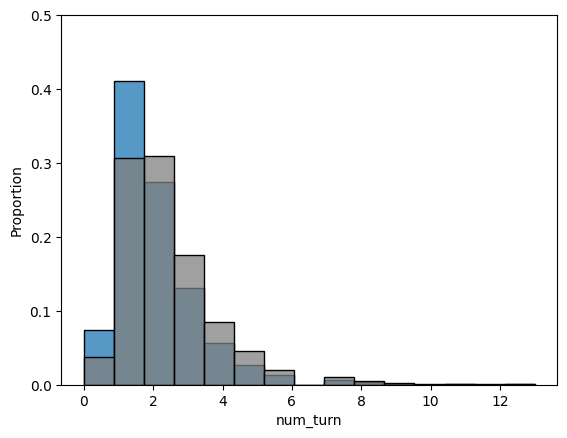

In [327]:
test = long_nostart[long_nostart.task=='oa']
sns.histplot(test,x='num_turn',stat='proportion',color='tab:blue',bins=15)
test = long_nostart[long_nostart.task=='oadark']
sns.histplot(test,x='num_turn',stat='proportion',color='grey',bins=15)
plt.ylim(0,.5)

(0.0, 0.7)

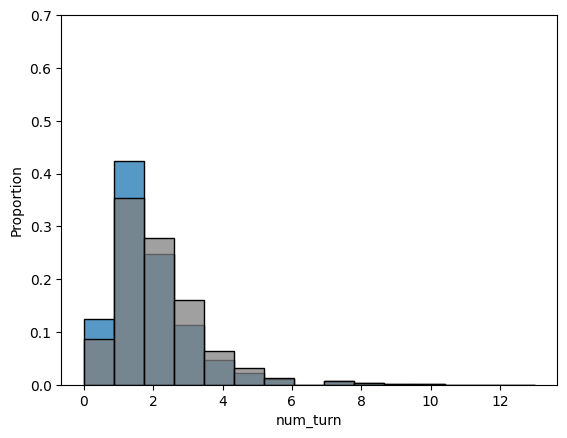

In [312]:
test = joint[joint.task=='oa']
sns.histplot(test,x='num_turn',stat='proportion',color='tab:blue',bins=15)
test = joint[joint.task=='oadark']
sns.histplot(test,x='num_turn',stat='proportion',color='grey',bins=15)
plt.ylim(0,.7)

(0.0, 0.5)

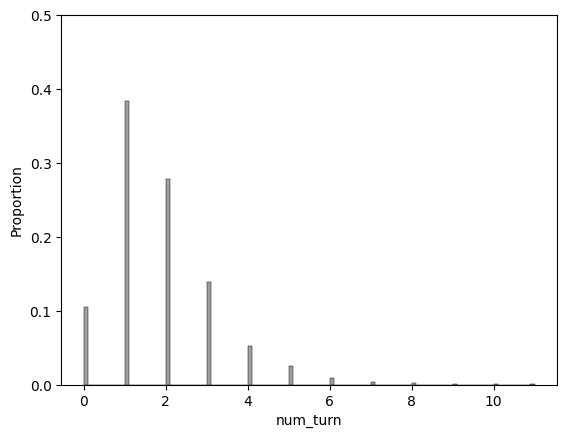

In [286]:
test = joint[joint.task=='oadark']
sns.histplot(test,x='num_turn',stat='proportion',color='grey')
plt.ylim(0,.5)

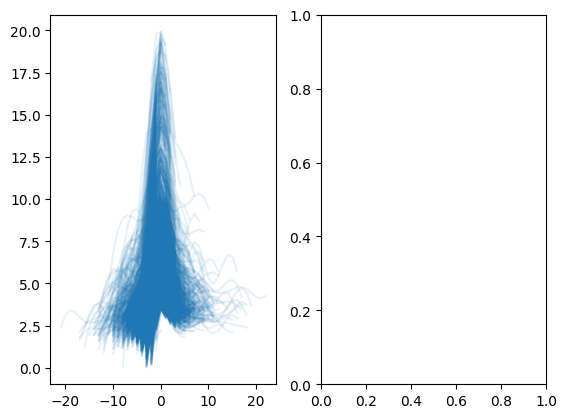

In [71]:
fig,ax = plt.subplots(1,2)
head_turns =  []
test = long_nostart[long_nostart.task=='oa']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)== 0:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[0].plot(fake_time,turn,c = 'tab:blue',alpha = .1)

In [162]:
prop

{'peak_heights': array([8.00372789, 5.37105057]),
 'prominences': array([7.93377446, 1.27337768]),
 'left_bases': array([18, 44], dtype=int64),
 'right_bases': array([44, 54], dtype=int64),
 'widths': array([5.94366393, 5.02261891]),
 'width_heights': array([4.03684066, 4.73436173]),
 'left_ips': array([28.84643729, 47.98969048]),
 'right_ips': array([34.79010121, 53.01230939])}

In [184]:
head_turns =  []
resample_turns = []
fake_time_arr = []
test = long_nostart[long_nostart.task=='oa'].sample(1)
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,10),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]-10:inds[i][1]+10]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time)
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

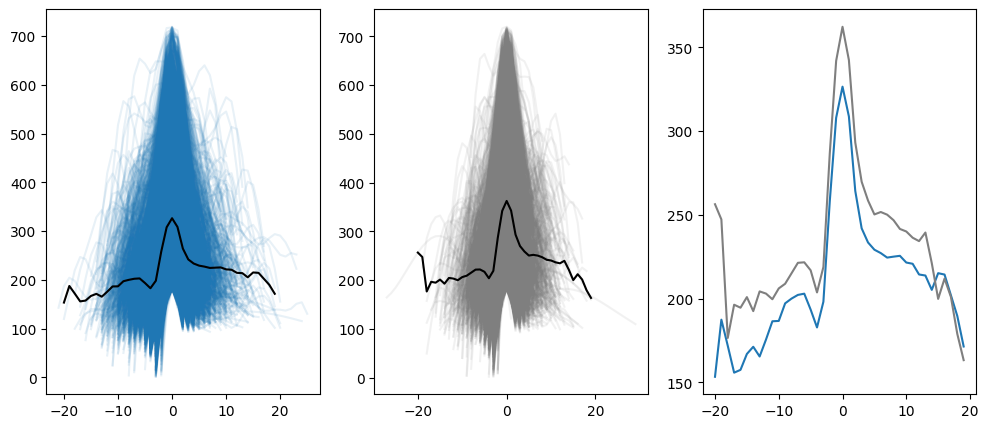

In [63]:
fig,ax = plt.subplots(1,3,figsize = (12,5))
head_turns =  []
resample_turns = []
fake_time_arr = []
xnew = np.arange(-20, 20, 1)

light = joint[(joint.task=='oa')]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3,12),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[0].plot(fake_time_arr[idx],turn*60,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')
ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:blue')

dark = joint[(joint.task=='oadark')]
head_turns =  []
resample_turns = []
fake_time_arr = []
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3,12),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[1].plot(fake_time_arr[idx],turn*60,c = 'tab:grey',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[1].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')

ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:grey')






(-22.0, 22.0)

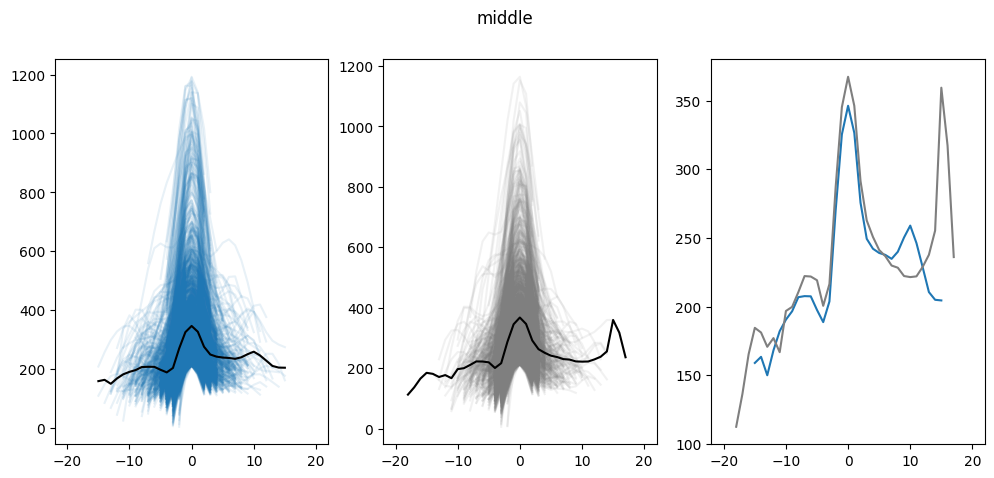

In [61]:
fig,ax = plt.subplots(1,3,figsize = (12,5))
head_turns =  []
resample_turns = []
fake_time_arr = []
xnew = np.arange(-20, 20, 1)

light = middle[middle.task=='oa']
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[0].plot(fake_time_arr[idx],turn*60,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')
ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:blue')

dark = middle[middle.task=='oadark']
head_turns =  []
resample_turns = []
fake_time_arr = []
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[1].plot(fake_time_arr[idx],turn*60,c = 'tab:grey',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[1].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')

ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:grey')

fig.suptitle('middle')

ax[0].set_xticks([-20,-10,0,10,20])
ax[0].set_xlim([-22,22])
ax[1].set_xticks([-20,-10,0,10,20])
ax[1].set_xlim([-22,22])
ax[2].set_xlim([-22,22])


(-22.0, 22.0)

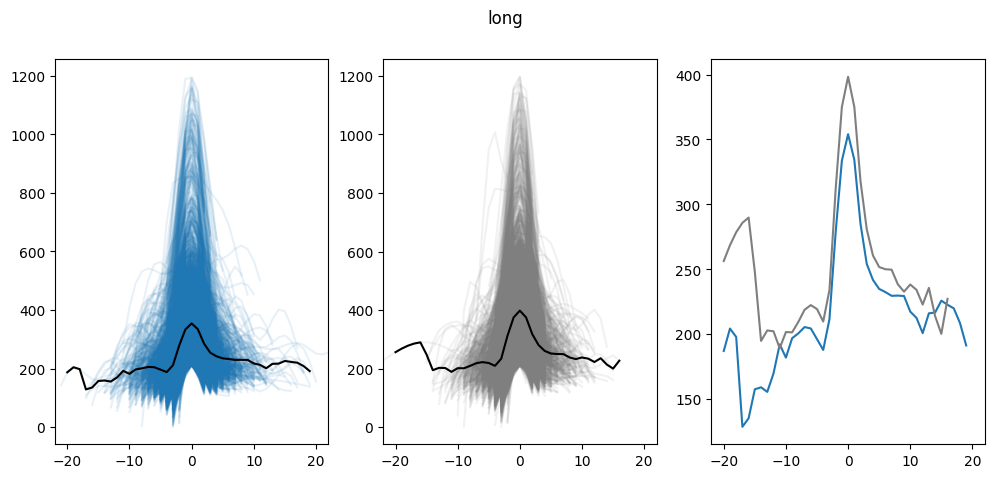

In [60]:
fig,ax = plt.subplots(1,3,figsize = (12,5))
head_turns =  []
resample_turns = []
fake_time_arr = []
xnew = np.arange(-20, 20, 1)

light = long_nostart[long_nostart.task=='oa']
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[0].plot(fake_time_arr[idx],turn*60,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')
ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:blue')

dark = long_nostart[long_nostart.task=='oadark']
head_turns =  []
resample_turns = []
fake_time_arr = []
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[1].plot(fake_time_arr[idx],turn*60,c = 'tab:grey',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[1].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')

ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:grey')

fig.suptitle('long')

ax[0].set_xticks([-20,-10,0,10,20])
ax[0].set_xlim([-22,22])
ax[1].set_xticks([-20,-10,0,10,20])
ax[1].set_xlim([-22,22])
ax[2].set_xlim([-22,22])


In [37]:
prop['peak_heights'].tolist()

TypeError: '>' not supported between instances of 'list' and 'int'

In [38]:
light_peaks

[3.975730695107509,
 3.538385458538178,
 6.072763103973279,
 15.569129944360563,
 70.76484211201341,
 26.86809405769425,
 4.829354357448666,
 6.900105355577886,
 11.687030545744493,
 7.111557642056977,
 14.397659479053353,
 5.381416681158556,
 5.169556264047671,
 4.847588182779208,
 27.177322177033663,
 3.6578902681437153,
 4.43656846495502,
 72.38060236024685,
 3.940478340111939,
 4.557689693284192,
 7.003432598052099,
 7.6032051134211365,
 5.953670572508479,
 17.136954144016656,
 3.7083109809332595,
 6.538083132903461,
 5.369580140686872,
 4.44617167523239,
 4.699180267353603,
 4.293316956236864,
 4.245249014989175,
 6.42267061039898,
 3.7524647133396627,
 4.65335006642784,
 5.324008189476151,
 12.533448598247654,
 4.766667038440778,
 4.132693964451621,
 4.1903282664220765,
 7.728046049762892,
 3.7394393688122607,
 7.202663525242366,
 3.54485917613955,
 6.787049030609671,
 5.207131577948483,
 5.0368997821837596,
 4.798784772270819,
 6.389293197825119,
 3.554834348451763,
 7.617762652

Text(0.5, 0.98, 'peak head velocity')

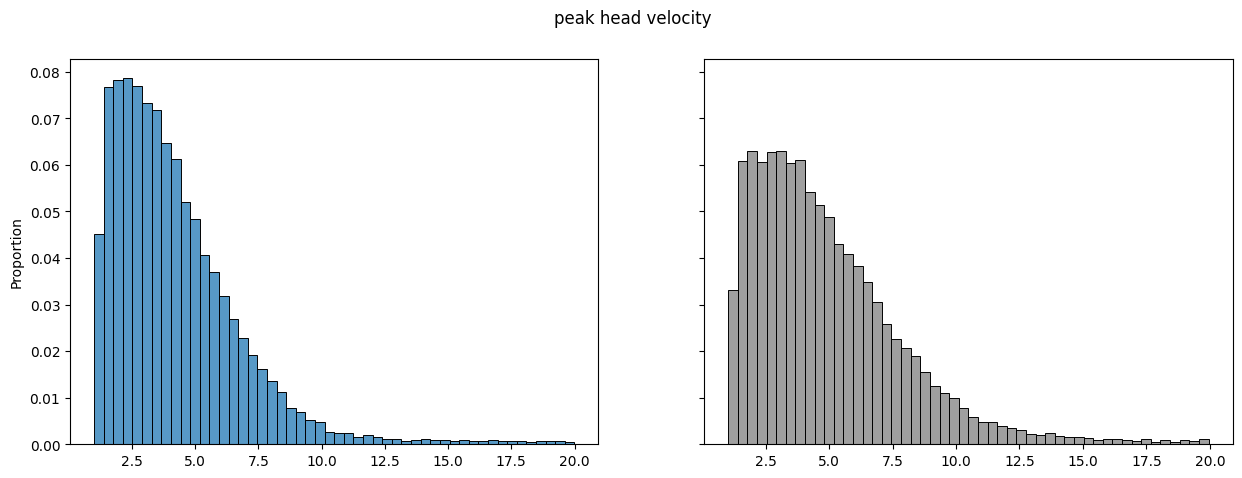

In [67]:
fig,ax = plt.subplots(1,2,sharey=True, figsize = (15,5))
light = joint[joint.task=='oa']
dark = joint[joint.task=='oadark']
light_peaks = []
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(1),prominence=1)
    light_peaks.extend(prop['peak_heights'].tolist())
light_peaks = np.asarray(light_peaks)

dark_peaks = []
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(1),prominence=1)
    dark_peaks.extend(prop['peak_heights'].tolist())
dark_peaks = np.asarray(dark_peaks)
sns.histplot(data=light_peaks[np.where(light_peaks<20)],ax = ax[0],stat='proportion',bins=50)
sns.histplot(data=dark_peaks[np.where(dark_peaks<20)],ax = ax[1],stat='proportion',color = 'grey',bins=50)
fig.suptitle('peak head velocity')


In [43]:
light_peaks

array([3.9757307 , 3.53838546, 6.0727631 , ..., 7.23877128, 5.03386236,
       6.96766914])

In [48]:
light_peaks[np.where(light_peaks<20)]


array([3.9757307 , 3.53838546, 6.0727631 , ..., 7.23877128, 5.03386236,
       6.96766914])

(-22.0, 22.0)

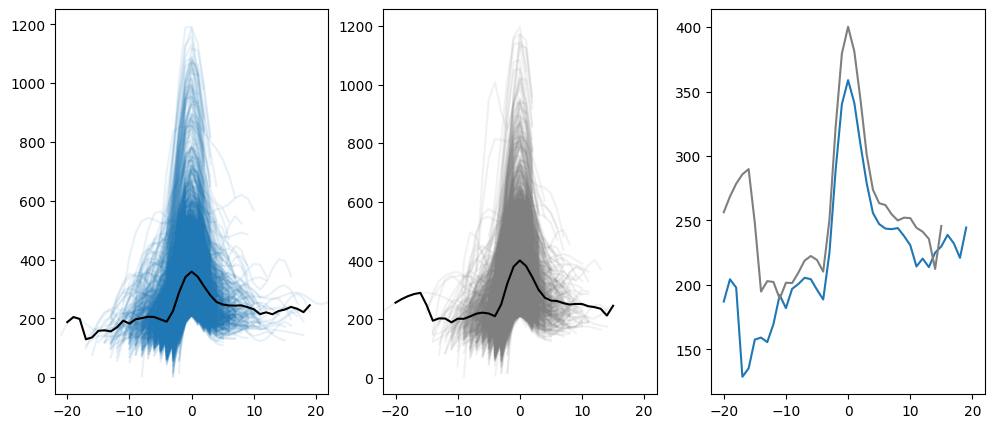

In [28]:
fig,ax = plt.subplots(1,3,figsize = (12,5))
head_turns =  []
xnew = np.arange(-20, 20, 1)
resample_turns = []
test = long_nostart[long_nostart.task=='oa']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)<= 5:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[0].plot(fake_time,turn*60,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time,turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')
ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:blue')

test = long_nostart[long_nostart.task=='oadark']
head_turns =  []
resample_turns = []
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)<= 5:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[1].plot(fake_time,turn*60,c = 'tab:grey',alpha = .1)

        interpolater = interp1d(fake_time,turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[1].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')

ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:grey')

ax[0].set_xticks([-20,-10,0,10,20])
ax[0].set_xlim([-22,22])
ax[1].set_xticks([-20,-10,0,10,20])
ax[1].set_xlim([-22,22])
ax[2].set_xlim([-22,22])


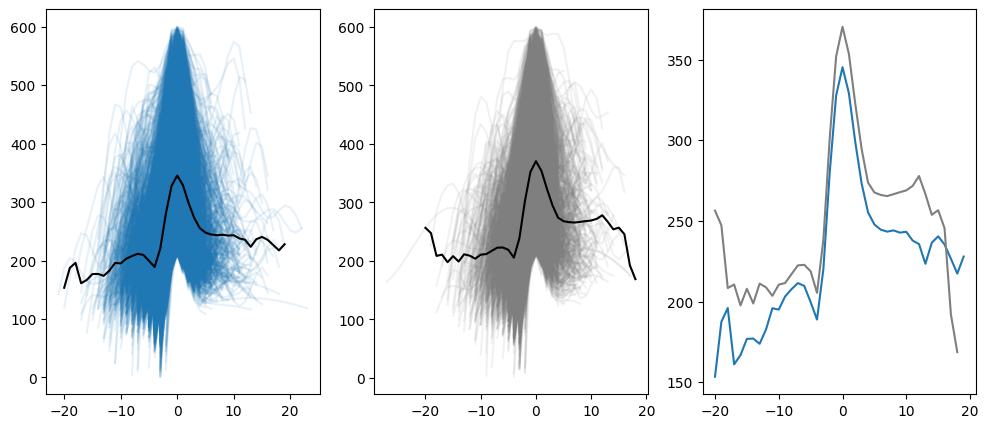

In [137]:
fig,ax = plt.subplots(1,3,figsize = (12,5))
head_turns =  []
xnew = np.arange(-20, 20, 1)
resample_turns = []
test = joint[joint.task=='oa']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,10),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)<= 5:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[0].plot(fake_time,turn*60,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time,turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')
ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:blue')

test = joint[joint.task=='oadark']
head_turns =  []
resample_turns = []
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,10),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)<= 5:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[1].plot(fake_time,turn*60,c = 'tab:grey',alpha = .1)

        interpolater = interp1d(fake_time,turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[1].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')

ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:grey')

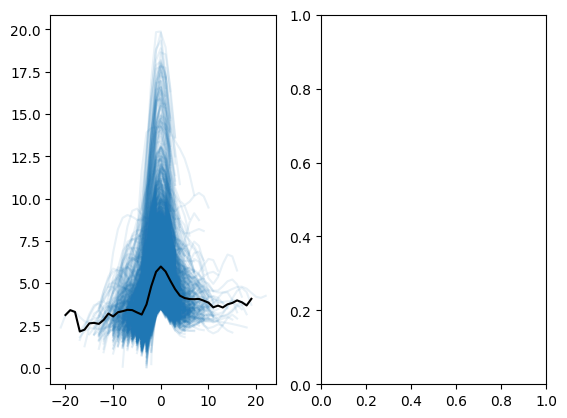

In [114]:
fig,ax = plt.subplots(1,2)
head_turns =  []
xnew = np.arange(-20, 20, 1)
resample_turns = []
test = long_nostart[long_nostart.task=='oa']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)<= 5:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[0].plot(fake_time,turn,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time,turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0),c = 'black')


In [102]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-60, 60, 1)
data = pd.concat([long,short])
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].head_corner_angle_velocity[:ob_ind]*60
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = pd.Series(ynew).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = trace.to_numpy()
           

            angle_array[i] = trace
    drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmedian(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'black',alpha = 1)

array([2.65204184, 2.65619321, 2.96757409, 3.42213606, 3.87910408,
       4.2650293 , 4.56165855, 4.77943879, 4.9442515 , 5.08487556,
       5.22122935, 5.36014964, 5.49765145, 5.62264195, 5.7201327 ,
       5.7775556 , 5.7905446 , 5.76513491, 5.71590552, 5.66021305,
       5.61132192, 5.57426405, 5.54049789, 5.4836691 , 5.36253417,
       5.13265581, 4.75953165, 4.23378687, 3.60536649, 3.01160189])

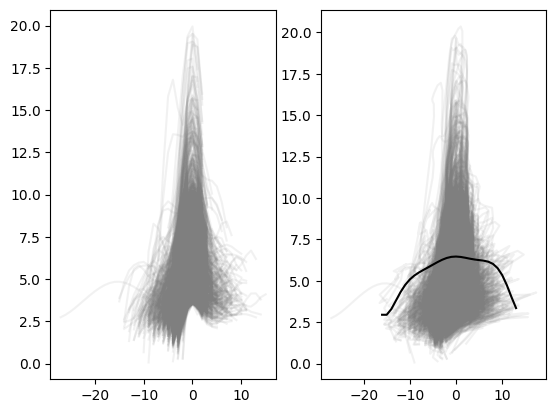

In [103]:
fig,ax = plt.subplots(1,2)
head_turns =  []
resample_turns = []
resample_faketime_arr = []
test = long_nostart[long_nostart.task=='oadark']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    if len(turn)<= 5:
        continue
    else: 
        fake_time = create_monotonic_array(len(turn),turn.argmax())
        ax[0].plot(fake_time,turn,c = 'tab:grey',alpha = .1)

        resample_time = signal.resample(fake_time,30)
        resample_turn = signal.resample(turn,30) 
        resample_turns.append(resample_turn)
        resample_faketime_arr.append(resample_time)
        ax[1].plot(resample_time,resample_turn,c = 'tab:grey',alpha = .1)

mean_time = create_monotonic_array(len(np.mean(resample_turns,axis=0)),np.mean(resample_turns,axis=0).argmax())
ax[1].plot(mean_time,np.mean(resample_turns,axis=0),c = 'black')

In [104]:
np.mean(resample_turns,axis=0)

array([2.94456753, 2.94260012, 3.28658386, 3.79901683, 4.3152161 ,
       4.74766301, 5.07569763, 5.31653482, 5.50155862, 5.66058081,
       5.81410931, 5.97026309, 6.12477261, 6.26492175, 6.37474272,
       6.4411454 , 6.45963615, 6.4365658 , 6.38747947, 6.33106473,
       6.28207603, 6.24516845, 6.2096748 , 6.14785684, 6.0162322 ,
       5.76212871, 5.33978671, 4.73785439, 4.01879968, 3.34770141])

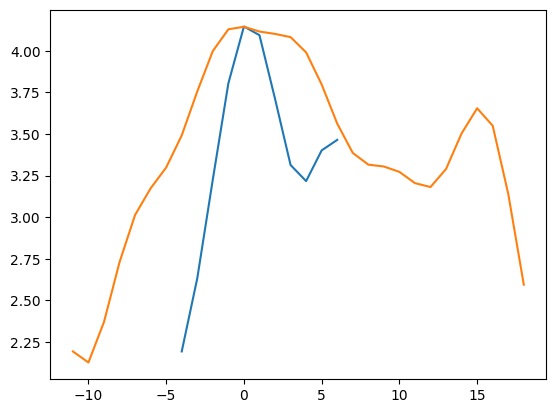

In [90]:
fake_time = create_monotonic_array(len(turn),turn.argmax())
plt.plot(fake_time,turn)

resample_turn = signal.resample(turn,30)
fake_time = create_monotonic_array(len(resample_turn),resample_turn.argmax()) 
plt.plot(fake_time,resample_turn)

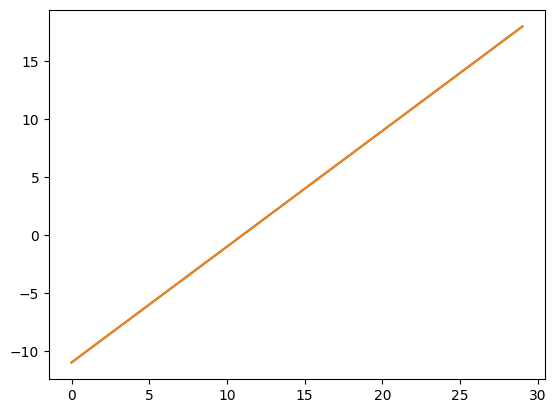

In [95]:
plt.plot(fake_time)
plt.plot(signal.resample(fake_time,30))


In [93]:
signal.resample(fake_time,30)

array([-1.10000000e+01, -1.00000000e+01, -9.00000000e+00, -8.00000000e+00,
       -7.00000000e+00, -6.00000000e+00, -5.00000000e+00, -4.00000000e+00,
       -3.00000000e+00, -2.00000000e+00, -1.00000000e+00, -1.89478063e-15,
        1.00000000e+00,  2.00000000e+00,  3.00000000e+00,  4.00000000e+00,
        5.00000000e+00,  6.00000000e+00,  7.00000000e+00,  8.00000000e+00,
        9.00000000e+00,  1.00000000e+01,  1.10000000e+01,  1.20000000e+01,
        1.30000000e+01,  1.40000000e+01,  1.50000000e+01,  1.60000000e+01,
        1.70000000e+01,  1.80000000e+01])

In [88]:
turn

array([2.1921661583929364, 2.632378007673386, 3.2268684187106067,
       3.804957135160253, 4.146346333795119, 4.094064285122224,
       3.7114547835885277, 3.3133236965630086, 3.2165292960176513,
       3.4012630989912034, 3.46436301101298], dtype=object)

In [87]:
resample_turn

array([2.19216616, 2.12588252, 2.3695877 , 2.72910522, 3.01311432,
       3.17317666, 3.29838206, 3.49135598, 3.75580496, 3.99877338,
       4.12944423, 4.14463464, 4.11595788, 4.10158289, 4.08231568,
       3.99044377, 3.79740886, 3.56242574, 3.38601181, 3.3155137 ,
       3.30429741, 3.27202446, 3.20430902, 3.1808901 , 3.28939493,
       3.5034068 , 3.65460248, 3.54929871, 3.13954006, 2.59382302])

In [86]:
fake_time

array([-11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,
         2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18])

ValueError: invalid number of data points (0) specified

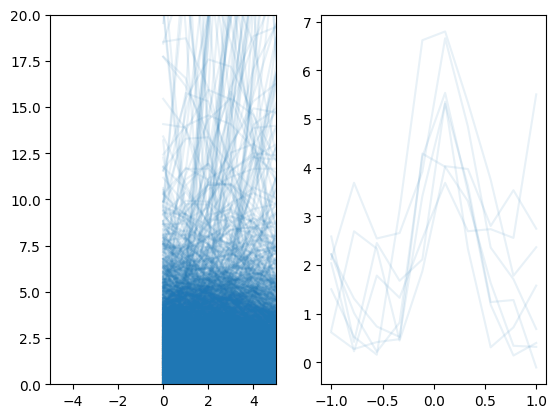

In [56]:
fig,ax = plt.subplots(1,2)
head_turns =  []
test = long_nostart[long_nostart.task=='oa']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]-10:inds[i][1]+11]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    ax[0].plot(turn,c = 'tab:blue',alpha = .1)

ax[0].set_ylim(0,20)
ax[0].set_xlim(-5,5)
resample_turns = []
for turn in head_turns:
    resample_turn = signal.resample(turn,10)
    resample_turns.append(resample_turn)
    ax[1].plot(np.linspace(-1,1,10),resample_turn,c = 'tab:blue',alpha = .1)
resample_turns = np.asarray(resample_turns)
ax[1].plot(np.linspace(-1,1,10),np.mean(resample_turns,axis=0),c = 'black')

ax[1].set_ylim(0,20)
ax[1].set_xlim(-5,5)

(-5.0, 5.0)

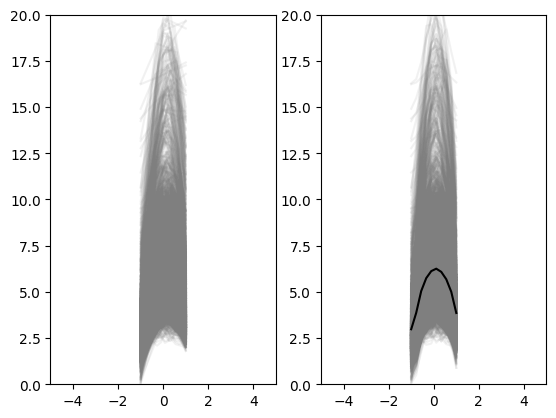

In [53]:
fig,ax = plt.subplots(1,2)
head_turns =  []
test = long_nostart[long_nostart.task=='oadark']
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3.5,20),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        head_turns.append(turn)
head_turns = np.asarray(head_turns)

for turn in head_turns:
    ax[0].plot(np.linspace(-1,1,len(turn)),turn,c = 'tab:grey',alpha = .1)

ax[0].set_ylim(0,20)
ax[0].set_xlim(-5,5)
resample_turns = []
for turn in head_turns:
    resample_turn = signal.resample(turn,10)
    resample_turns.append(resample_turn)
    ax[1].plot(np.linspace(-1,1,10),resample_turn,c = 'tab:grey',alpha = .1)
resample_turns = np.asarray(resample_turns)
ax[1].plot(np.linspace(-1,1,10),np.mean(resample_turns,axis=0),c = 'black')

ax[1].set_ylim(0,20)
ax[1].set_xlim(-5,5)

In [19]:
np.median(resample_turns,axis=0)

array([2.75827073, 3.56534061, 4.60516102, 5.18961912, 5.47480485,
       5.53378252, 5.40835177, 5.09978573, 4.54332242, 3.56940833])

In [23]:
6.2*60

372.0

In [ ]:

for turn in head_turns:
    plt.plot(np.linspace(-1,1,len(turn)),turn)
plt.ylim(0,20)
plt.xlim(-15,15)

In [ ]:
peaks

In [ ]:
np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[57:67]

In [ ]:
plt.plot(np.linspace(-1,1,10),np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[57:67])

In [ ]:
test[0]

In [ ]:
np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[test[2][0]:test[2][1]]

In [ ]:
peaks

In [554]:
test = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T

In [ ]:
prop['right_ips'].astype(int)

In [ ]:
prop['left_ips'].astype(int)

In [ ]:
prop['right_bases']

In [ ]:
prop['left_bases']

In [ ]:
prop['prominences']

In [ ]:
len(peaks)

In [ ]:
500/60


In [ ]:
peaks

In [ ]:
prop['prominences']

In [ ]:
prop['peak_heights']

In [ ]:
peaks[prop['peak_heights'].argmax()]

In [ ]:
row.ts_distance_from_edge[:int(row.obstacle_ind)][15]

In [ ]:
row.ts_distance_from_edge[:int(row.obstacle_ind)][15]

In [ ]:
row.ts_distance_from_edge

In [ ]:
np.where(row.ts_distance_from_edge == row.ts_distance_from_edge[:int(row.obstacle_ind)][15])[0][0]

In [ ]:
len(row.ts_nose_x_cm)

In [ ]:
prop['widths']

In [ ]:
prop['widths'].argmax()

In [ ]:
max_peak = df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]

In [498]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3.5,20))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
        #df.at[ind,'distance_traveled_at_head_turn'] = sum(row.ts_distance[:int(row.obstacle_ind)][:max_peak-1])
        #df.at[ind,'head_corner_angle_velocity_at_head_turn'] = row.head_corner_angle_velocity[:int(row.obstacle_ind)].min()


In [ ]:
long

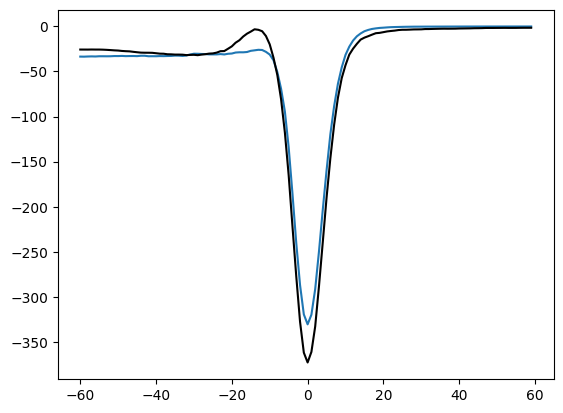

In [108]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-60, 60, 1)
data = pd.concat([long,short])
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].head_corner_angle_velocity[:ob_ind]*60
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = pd.Series(ynew).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = trace.to_numpy()
           

            angle_array[i] = trace
    drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmedian(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'black',alpha = 1)

In [ ]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-60, 60, 1)
data = pd.concat([long,short])
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].ts_zero_out_angle_to_corner[:ob_ind]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = pd.Series(ynew).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = trace.to_numpy()
           

            angle_array[i] = trace
    drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmedian(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_median,c = 'black',alpha = 1)

In [ ]:
joint.head_angle

In [ ]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-100, 100, 1)
data = pd.concat([long,short])
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].ts_speed[:ob_ind]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = pd.Series(ynew).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = trace.to_numpy()
           

            angle_array[i] = trace
    drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmean(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_median,c = 'black',alpha = 1)

Text(0.5, 0, 'frames')

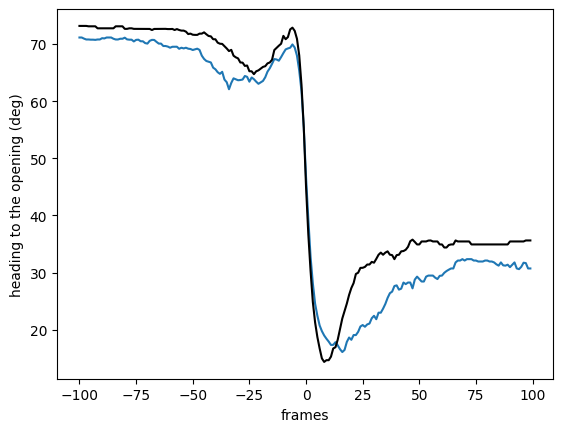

In [75]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-100, 100, 1)
data = pd.concat([long])
data = data[data.date_index == 0 ]
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].ts_angle_to_corner[:ob_ind]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = ynew
            trace = pd.Series(trace).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = smooth(trace)
           

            angle_array[i] = trace
    #drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    #angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmedian(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        light_median= np.nanmedian(light_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,light_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_median= np.nanmedian(dark_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        ax.plot(xnew,dark_median,c = 'black',alpha = 1)
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('frames')

In [ ]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-100, 100, 1)
data = pd.concat([long])
data = data[data.date_index == 0 ]
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].ts_angle_to_corner[:ob_ind]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = ynew
            trace = pd.Series(trace).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = smooth(trace)
           

            angle_array[i] = trace
    #drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    #angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmedian(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        light_median= np.nanmedian(light_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,light_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_median= np.nanmedian(dark_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        ax.plot(xnew,dark_median,c = 'black',alpha = 1)
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('frames')
fig.suptitle('early')

In [ ]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-100, 100, 1)
data = pd.concat([long])
data = data[data.date_index == 5 ]
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_corner_angle_velocity[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_corner_angle_velocity[:ob_ind]),thresh)
        y = row[1].ts_angle_to_corner[:ob_ind]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = ynew
            trace = pd.Series(trace).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            trace = smooth(trace)
           

            angle_array[i] = trace
    #drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    #angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmedian(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        light_median= np.nanmedian(light_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,light_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_median= np.nanmedian(dark_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        ax.plot(xnew,dark_median,c = 'black',alpha = 1)
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('frames')
fig.suptitle('late')

In [ ]:
dark_median.min()

In [ ]:
len(y)

Text(0.5, 0, 'frames')

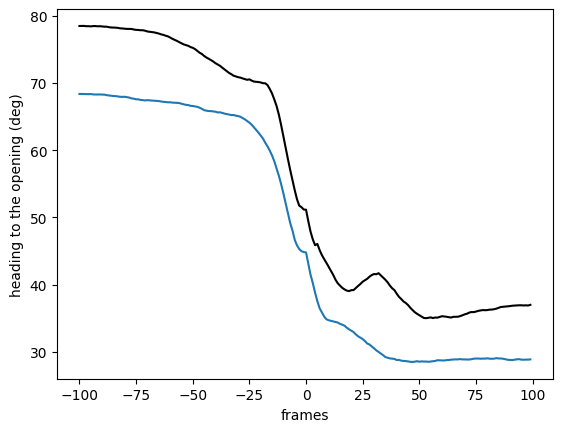

In [74]:
fig,ax = plt.subplots()
#ax.set_xlim(-100,100)
xnew = np.arange(-100, 100, 1)
data = pd.concat([long])
for date,date_df in  data.groupby(['task']):
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan
    for i,row in enumerate(date_df.iterrows()):
        ob_ind = int(row[1].obstacle_ind)
        thresh = row[1].head_angle[:ob_ind].argmin()
        x =create_monotonic_array(len(row[1].head_angle[:ob_ind]),thresh)
        y = row[1].ts_angle_to_corner[:ob_ind]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            trace = ynew
            trace = pd.Series(trace).interpolate(limit_direction ='backward')
            trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
            #race = smooth(trace)
           

            angle_array[i] = trace
    #drop = np.argwhere(sum(np.isnan(angle_array.T))>0)
    #angle_array = np.delete(angle_array, drop, axis=0)

    date_angle_median= np.nanmean(angle_array,axis = 0)
    if date == 'oa':
        light_array = angle_array
        light_median= np.nanmean(light_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        #ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,light_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_median= np.nanmean(dark_array,axis = 0)
        #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
        ax.plot(xnew,dark_median,c = 'black',alpha = 1)
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('frames')

In [ ]:
plt.plot(np.tile(xnew,(len(light_array),1)).T[:,:10],light_array.T[:,:10],color = 'tab:blue');

In [ ]:
plt.plot(np.tile(xnew,(len(light_array),1)).T[:,:10],smooth(light_array.T[:,:10],sigma=1),color = 'tab:blue');

In [ ]:
#xnew = np.arange(-60, 60, 1)
plt.plot(np.tile(xnew,(len(light_array),1)).T[:,:10],light_array.T[:,:10],color = 'tab:blue');

In [ ]:
data = long[(long.obstacle_cluster == 5)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks(np.arange(-1,20,6))
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('lateral error (cm)')
    ax[1].set_xlabel('distance to obstacle')
    #ax[1].invert_yaxis()
  


    trial_df = data.loc[[ind]]
    plot_arena(trial_df,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(trial_df.obstacle_cluster.unique()))

    for ind,row in trial_df.iterrows():
        
        #
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = row.head_corner_angle_velocity[:ob_ind].argmin()
        thresh_angle = row.head_corner_angle_velocity[:ob_ind].argmin()
        sacc_x =create_monotonic_array(len(row.head_corner_angle_velocity[:ob_ind]),thresh)
  
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:grey')
        ax[1].plot(sacc_x,row.head_corner_angle_velocity[:ob_ind],color = 'tab:grey')
        ax[2].plot(sacc_x,smooth(row.ts_angle_to_corner)[:ob_ind],color = 'tab:grey')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[:ob_ind][thresh],smooth(row.ts_nose_y_cm)[:ob_ind][thresh],color = 'tab:red')
        ax[1].scatter(sacc_x[thresh],row.head_corner_angle_velocity[:ob_ind][thresh],color = 'tab:red')
        ax[2].scatter(sacc_x[thresh],row.ts_angle_to_corner[:ob_ind][thresh],color = 'tab:red')
        #ax[0].scatter(smooth(row.ts_nose_x_cm)[:ob_ind][thresh_angle],smooth(row.ts_nose_y_cm)[:ob_ind][thresh_angle],color = 'black')
        #ax[1].scatter(sacc_x[thresh_angle],row.head_corner_angle_velocity[:ob_ind][thresh_angle],color = 'black')
        #ax[2].scatter(sacc_x[thresh_angle],smooth(row.ts_angle_to_corner)[:ob_ind][thresh_angle],color = 'black')

In [ ]:
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,0)
cor_x,cor_y = correct_trace(row,ob_x,ob_y)

In [ ]:
long

In [ ]:
data = long[(long.obstacle_cluster == 5)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(20)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks(np.arange(-1,20,6))
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('head_anglular_velocity')
    ax[1].set_xlabel('frames')
    ax[2].set_ylabel('head_corner_angle')
    ax[2].set_xlabel('frames')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    #plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))
    #ob_x,ob_y  = plot_orginal_obstacle(data,ax[0],5)


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        ob_x,ob_y  = plot_orginal_obstacle(trial_df,ax[0],5)
        cor_x,cor_y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        #thresh_angle = row.ts_angle_to_corner[:ob_ind].argmin()
        #sacc_x =create_monotonic_array(len(row.head_corner_angle_velocity[:ob_ind]),thresh)
  
        ax[0].plot(cor_x,cor_y,color = 'black')
        ax[1].plot(row.head_angle_velocity[:ob_ind],color = 'black')
        ax[2].plot(row.ts_angle_to_corner[:ob_ind],color = 'black')
        ax[0].scatter(cor_x[:ob_ind][thresh],cor_y[:ob_ind][thresh],color = 'tab:red')
        ax[1].scatter(np.where( row.head_angle_velocity == row.head_angle_velocity[:ob_ind][thresh])[0][0],row.head_angle_velocity[:ob_ind][thresh])
        ax[2].scatter(np.where( row.ts_angle_to_corner == row.ts_angle_to_corner[:ob_ind][thresh])[0][0],row.ts_angle_to_corner[:ob_ind][thresh])

In [ ]:
data = long[(long.obstacle_cluster == 5)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(10)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks(np.arange(-1,20,6))
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('head_anglular_velocity')
    ax[1].set_xlabel('frames')
    ax[2].set_ylabel('head_corner_angle')
    ax[2].set_xlabel('frames')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    #plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))
    ob_x,ob_y  = plot_orginal_obstacle(data,ax[0],5)


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        cor_x,cor_y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        #thresh_angle = row.ts_angle_to_corner[:ob_ind].argmin()
        #sacc_x =create_monotonic_array(len(row.head_corner_angle_velocity[:ob_ind]),thresh)
  
        ax[0].plot(cor_x,cor_y,color = 'tab:blue')
        ax[1].plot(row.head_angle_velocity[:ob_ind],color = 'tab:blue')
        ax[2].plot(row.ts_angle_to_corner[:ob_ind],color = 'tab:blue')
        ax[0].scatter(cor_x[:ob_ind][thresh],cor_y[:ob_ind][thresh],color = 'tab:red')
        ax[1].scatter(np.where( row.head_angle_velocity == row.head_angle_velocity[:ob_ind][thresh])[0][0],row.head_angle_velocity[:ob_ind][thresh])
        ax[2].scatter(np.where( row.ts_angle_to_corner == row.ts_angle_to_corner[:ob_ind][thresh])[0][0],row.ts_angle_to_corner[:ob_ind][thresh])
        

In [ ]:
np.where( row.head_angle_velocity == row.head_angle_velocity[:ob_ind][thresh])[0][0]

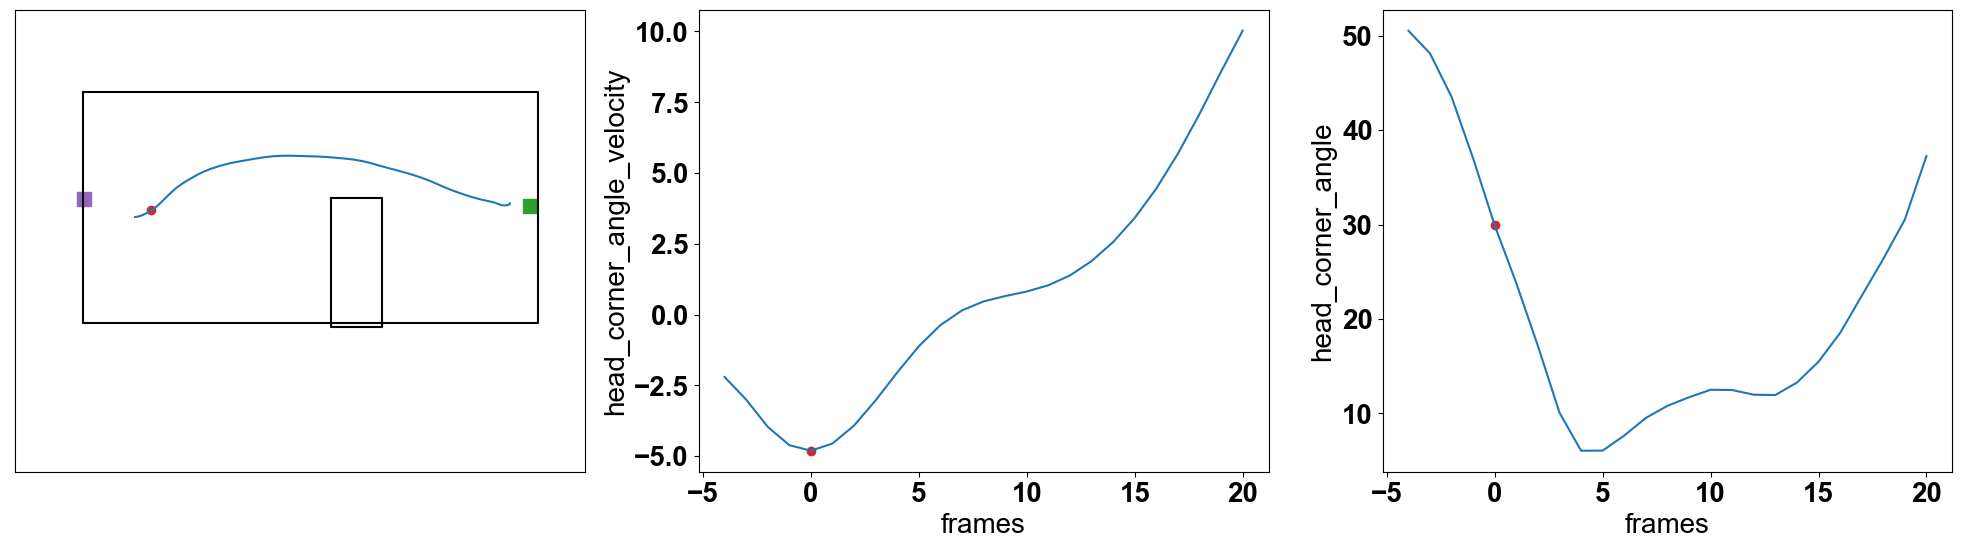

In [128]:
data = long[(long.obstacle_cluster == 5)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks(np.arange(-1,20,6))
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('head_corner_angle_velocity')
    ax[1].set_xlabel('frames')
    ax[2].set_ylabel('head_corner_angle')
    ax[2].set_xlabel('frames')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    #plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))
    ob_x,ob_y  = plot_orginal_obstacle(data,ax[0],5)


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        cor_x,cor_y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = row.head_corner_angle_velocity[:ob_ind].argmin()
        thresh_angle = row.ts_angle_to_corner[:ob_ind].argmin()
        sacc_x =create_monotonic_array(len(row.head_corner_angle_velocity[:ob_ind]),thresh)
  
        ax[0].plot(cor_x,cor_y,color = 'tab:blue')
        ax[1].plot(sacc_x,smooth(row.head_corner_angle_velocity)[:ob_ind],color = 'tab:blue')
        ax[2].plot(sacc_x,smooth(row.ts_angle_to_corner)[:ob_ind],color = 'tab:blue')
        ax[0].scatter(cor_x[:ob_ind][thresh],cor_y[:ob_ind][thresh],color = 'tab:red')
        ax[1].scatter(sacc_x[thresh],smooth(row.head_corner_angle_velocity)[:ob_ind][thresh],color = 'tab:red')
        ax[2].scatter(sacc_x[thresh],smooth(row.ts_angle_to_corner)[:ob_ind][thresh],color = 'tab:red')
        


      

In [ ]:
fig,ax = plt.subplots()
ax.plot(row.ts_distance_from_target_port[ob_ind:],smooth(row.ts_angle_to_target_port[ob_ind:]))
ax.invert_xaxis()

In [ ]:
data = long[(long.obstacle_cluster == 5)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,3,figsize=(25,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    #ax[1].set_xticks(np.arange(-1,20,6))
    #ax[1].set_xlim(-1,20)
    #ax[1].invert_xaxis()
    ax[1].set_ylabel('head_corner_angle_velocity')
    ax[1].set_xlabel('frames')
    ax[2].set_ylabel('head_corner_angle')
    ax[2].set_xlabel('frames')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    #plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))
    ob_x,ob_y  = plot_orginal_obstacle(data,ax[0],5)


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        cor_x,cor_y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
        thresh = row.head_corner_angle_velocity[:ob_ind].argmin()
        thresh_angle = row.ts_angle_to_corner[:ob_ind].argmin()
        sacc_x =create_monotonic_array(len(row.head_corner_angle_velocity[:ob_ind]),thresh)
  
        ax[0].plot(cor_x,cor_y,color = 'tab:grey')
        ax[1].plot(sacc_x,smooth(row.head_corner_angle_velocity)[:ob_ind],color = 'tab:grey')
        ax[2].plot(sacc_x,smooth(row.ts_angle_to_corner)[:ob_ind],color = 'tab:grey')
        ax[0].scatter(cor_x[:ob_ind][thresh],cor_y[:ob_ind][thresh],color = 'tab:red')
        ax[1].scatter(sacc_x[thresh],smooth(row.head_corner_angle_velocity)[:ob_ind][thresh],color = 'tab:red')
        ax[2].scatter(sacc_x[thresh],smooth(row.ts_angle_to_corner)[:ob_ind][thresh],color = 'tab:red')

In [ ]:
fig,ax = plt.subplots()
ax.plot(row.ts_distance_from_target_port[ob_ind:],smooth(row.ts_angle_to_target_port[ob_ind:]))
ax.invert_xaxis()

In [ ]:
row.ts_angle_to_target_port[ob_ind:]

In [ ]:
trace = pd.Series(X_test[66]).interpolate(limit_direction ='backward')
trace = pd.Series(trace).interpolate(limit_direction ='forward')
trace = trace.to_numpy()
plt.plot(xnew,trace*60)

In [ ]:
xnew = np.arange(-60, 60, 1)
for i in pca.components_:
    fig,ax = plt.subplots()
    ax.plot(xnew,i)

In [243]:
pca = PCA(n_components=4)

X_train = pca.fit_transform(light_array)
#X_test = pca.transform(X_test.T)
pca
explained_variance = pca.explained_variance_ratio_

In [ ]:
explained_variance

In [ ]:
for i in pca.components_:
    fig,ax = plt.subplots()
    ax.plot(xnew,i)

In [ ]:
sns.violinplot(data = long_nostart,x='task',y='distance_at_head_turn')

In [ ]:
sns.violinplot(data = long,x='task',y='distance_at_head_turn')

In [ ]:

fig,ax = plt.subplots(layout = 'constrained',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn cm')
ax.set_ylabel('average lateral error cm')

data = long_nostart[long_nostart.task == 'oa']
data = data[data.turn_to_obstacle == 'towards']

#data = data[(data.head_corner_angle_velocity_at_head_turn >= -5) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .05,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


In [ ]:
long_con_nostart

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')
data = pd.concat([short_nostart,long_nostart])
data = data[data.task == 'oa']

data = data[(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')
data = pd.concat([short_nostart])
data = data[data.task == 'oa']

data = data[(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

In [ ]:
long

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long[long.task == 'oa']


data = data[(data.distance_at_head_turn_2 >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn_2.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .05,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

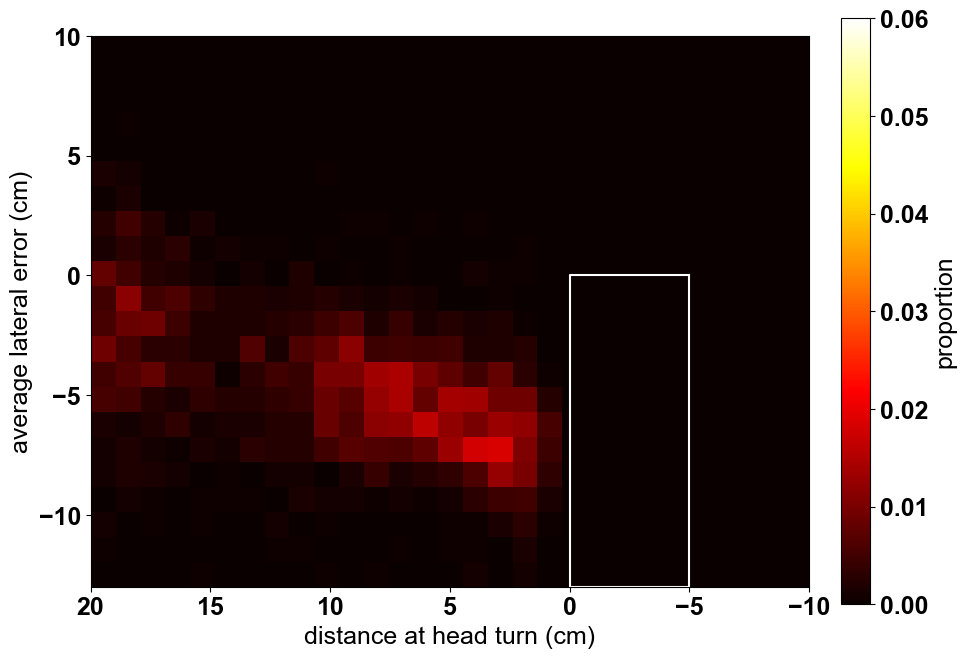

In [330]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long[long.task == 'oa']


data = data[(data.distance_at_head_turn_2 >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn_2.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .06,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

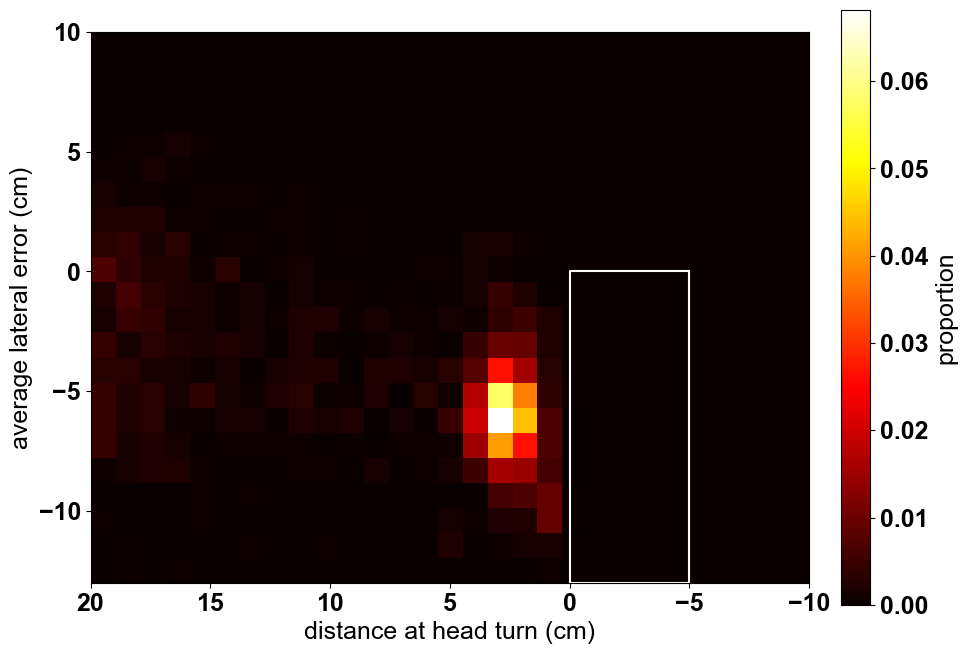

In [329]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long[long.task == 'oadark']


data = data[(data.distance_at_head_turn_2 >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn_2.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = short[short.task == 'oadark']


data = data[(data.distance_at_head_turn_2 >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn_2.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .12,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = short[short.task == 'oa']


data = data[(data.distance_at_head_turn_2 >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn_2.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .12,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long[long.task == 'oa']


data = data[(data.distance_at_head_turn_2 >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn_2.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .06,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 18}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long[long.task == 'oa']


data = data[(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .05,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()

Text(0.5, 1.0, 'light')

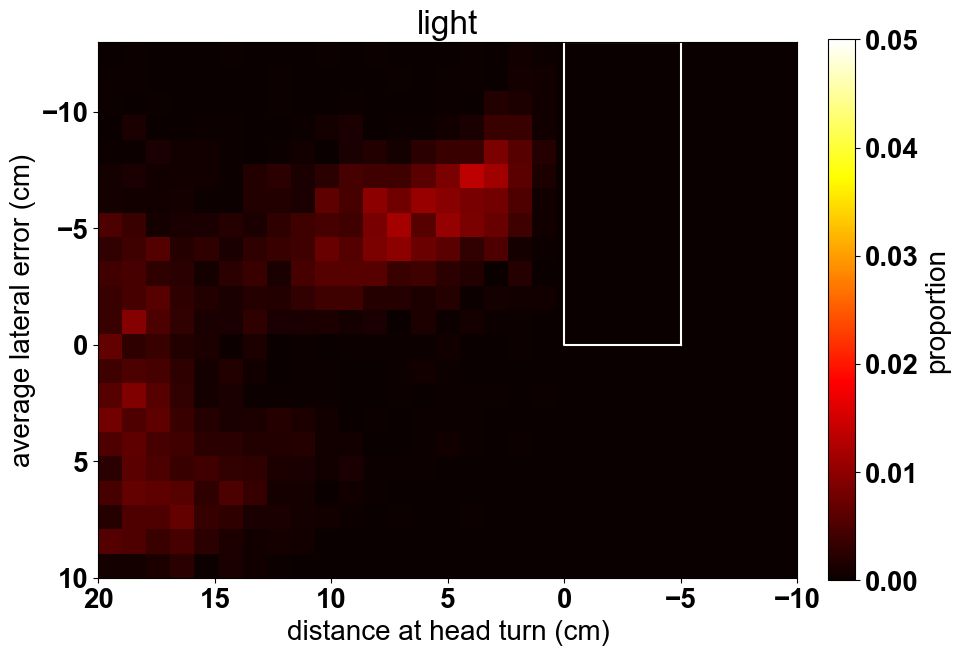

In [114]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 20}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long_nostart[long_nostart.task == 'oa']


data = data[(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .05,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title('light')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_light_heatmap.pdf')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_light_heatmap.png')

In [ ]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 20}

plt.rc( 'font',**font);

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn (cm)')
ax.set_ylabel('average lateral error (cm)')

data = long_nostart[long_nostart.task == 'oadark']


data = data[(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
cbar = fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .05,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
cbar.set_label('proportion')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title('dark')
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_dark_heatmap.pdf')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_dark_heatmap.png')

In [ ]:

fig,ax = plt.subplots(layout = 'tight',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn cm')
ax.set_ylabel('average lateral error cm')

data = long[long.task == 'oadark']


data = data[(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax.imshow(array[::-1]/len(data),cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)
ax.invert_xaxis()

In [ ]:

fig,ax = plt.subplots(layout = 'constrained',figsize=(10,7))


#gs = GridSpec(ncols=6, nrows=6,figure=fig)


ax.set_xlabel('distance at head turn cm')
ax.set_ylabel('average lateral error cm')

data = long_nostart[long_nostart.task == 'oadark']

#data = data[(data.head_corner_angle_velocity_at_head_turn >= -5) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))

#ax.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax.imshow(array[::-1]/len(data),vmax = .05,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


In [18]:
def correct_trace(row,ob_x,ob_y):
    input_ob_x, input_ob_y = row.gt_obstacleTL_x_cm ,row.gt_obstacleTL_y_cm
    direction = row.odd
    diff_x = input_ob_x - ob_x[0]
    diff_y = input_ob_y- ob_y[0]
    correct_y = 1*(diff_y)
    if direction == 'right':
        correct_x = -1*(diff_x)

    else:
        correct_x = diff_x
    return smooth(row.ts_nose_x_cm - diff_x) , smooth(row.ts_nose_y_cm- diff_y) 



In [ ]:
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,0)
cor_x,cor_y = correct_trace(row,ob_x,ob_y)

In [ ]:
data = long[long.task == 'oadark']
data = data[(data.distance_at_head_turn >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
data = data[data['animal'].isin(['J704RT', 'J704NN', 'J704LT', 'J704LN'])]

fig,ax = plt.subplots(layout = 'constrained',figsize=(10,7))


ax.set_xticks([])
ax.set_yticks([])

trace_ax = data[(data.obstacle_cluster == 5)&(data.odd == 'left')].sample(5)     
plot_arena(trace_ax,ax,0)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,0)
for ind,row in trace_ax.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='black', alpha =.5 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')

In [ ]:
data = long[long.task == 'oadark']
data = data[(data.distance_at_head_turn >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 5)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


ax.set_xticks([])
ax.set_yticks([])
mean_x = get_median_of_df(data,'ts_nose_x_cm',50)
mean_y=get_median_of_df(data,'ts_nose_y_cm',50)
trace_ax_dark = data[(data.obstacle_cluster == 5)&(data.odd == 'left')].sample(7)     
plot_arena(trace_ax_dark,ax,0)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax_dark,ax,0)
for ind,row in trace_ax_dark.iterrows():
    x = row.ts_nose_x_cm.astype(float)
    y = row.ts_nose_y_cm.astype(float)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='black', alpha =.3 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')
#ax.plot(smooth(mean_x),smooth(mean_y),c = 'black',linewidth=3.0, alpha =.9)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_dark_traces.pdf')

In [ ]:
long

In [ ]:
  before_x =  np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)],row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:]))[0]
    after_x =  np.where(np.in1d(row.ts_angle_to_corner[:int(row.obstacle_ind)],row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][:10]))[0]

In [354]:
def angle_to_corner_before_after_turn(df):
    for ind,row in df.iterrows():
        turn_index = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
        df.at[ind,'angle_to_corner_before'] = np.nanmean(row.ts_angle_to_corner[:int(row.obstacle_ind)][:turn_index][-10:])
        df.at[ind,'angle_to_corner_after'] = np.nanmean(row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:][-10:])
        df.at[ind,'speed_before'] = np.nanmean(row.ts_speed[:int(row.obstacle_ind)][:turn_index][-10:])
        df.at[ind,'speed_after'] = np.nanmean(row.ts_speed[:int(row.obstacle_ind)][turn_index:][-10:])




In [349]:
angle_to_corner_before_after_turn(long_nostart)

In [351]:
angle_to_corner_before_after_turn(long)

In [ ]:
fig,ax = plt.subplots(layout = 'tight')
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task',estimator = 'median',palette=['tab:blue','grey']) 
ax.set_yticks([0,5,10])
ax.set_ylabel('distance at turn (cm)')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])

In [ ]:

fig,ax = plt.subplots(layout = 'tight')
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'angle_to_corner_after',hue = 'task',estimator = 'mean',palette=['tab:blue','grey']) 
ax.set_yticks([0,30,60])
ax.set_ylabel('angle at turn (deg)')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])

fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/angle_at_head_turn_bar.pdf',dpi = 300)

In [ ]:

fig,ax = plt.subplots(1,2,layout = 'tight',sharey=True)
data = long[long.turn_to_obstacle=='towards']

sns.barplot(ax = ax[1], data = data ,x='task' ,y = 'angle_to_corner_after',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],errorbar=None) 
sns.barplot(ax = ax[0], data = data ,x='task' ,y = 'angle_to_corner_before',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],errorbar=None )
ax[0].set_xticks([0,1],['light','dark'])
ax[1].set_xticks([0,1],['light','dark'])
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('heading to opening (deg)')
ax[0].set_title('before turn')
ax[1].set_title('after turn')


light = data[data.task == 'oa']
light_mean_before = light.angle_to_corner_before.mean()
light_mean_after = light.angle_to_corner_after.mean()
light_before = np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
light_after= np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean_before = dark.angle_to_corner_before.mean()
dark_mean_after = dark.angle_to_corner_after.mean()
dark_before = np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
dark_after= np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

ax[0].errorbar([0,1],[light_mean_before,dark_mean_before] , yerr=[light_before,dark_before], ls='none' ,color="black")

ax[1].errorbar([0,1],[light_mean_after,dark_mean_after] , yerr=[light_after,dark_after], ls='none' ,color="black")

In [ ]:

fig,ax = plt.subplots(1,2,layout = 'tight',sharey=True)
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax[1], data = data ,x='task' ,y = 'angle_to_corner_after',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],errorbar=None) 
sns.barplot(ax = ax[0], data = data ,x='task' ,y = 'angle_to_corner_before',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],errorbar=None )
ax[0].set_xticks([0,1],['light','dark'])
ax[1].set_xticks([0,1],['light','dark'])
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('heading to opening (deg)')
ax[0].set_title('before turn')
ax[1].set_title('after turn')


light = data[data.task == 'oa']
light_mean_before = light.angle_to_corner_before.mean()
light_mean_after = light.angle_to_corner_after.mean()
light_before = np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
light_after= np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean_before = dark.angle_to_corner_before.mean()
dark_mean_after = dark.angle_to_corner_after.mean()
dark_before = np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
dark_after= np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

ax[0].errorbar([0,1],[light_mean_before,dark_mean_before] , yerr=[light_before,dark_before], ls='none' ,color="black")

ax[1].errorbar([0,1],[light_mean_after,dark_mean_after] , yerr=[light_after,dark_after], ls='none' ,color="black")

In [ ]:

fig,ax = plt.subplots(1,2,layout = 'tight',sharey=True)
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax[1], data = data ,x='task' ,y = 'angle_to_corner_after',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],errorbar=None) 
sns.barplot(ax = ax[0], data = data ,x='task' ,y = 'angle_to_corner_before',hue = 'task',estimator = 'mean',palette=['tab:blue','grey'],errorbar=None )
ax[0].set_xticks([0,1],['light','dark'])
ax[1].set_xticks([0,1],['light','dark'])
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('heading to opening (deg)')
ax[0].set_title('before movement')
ax[1].set_title('after movement')


light = data[data.task == 'oa']
light_mean_before = light.angle_to_corner_before.mean()
light_mean_after = light.angle_to_corner_after.mean()
light_before = np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
light_after= np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean_before = dark.angle_to_corner_before.mean()
dark_mean_after = dark.angle_to_corner_after.mean()
dark_before = np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
dark_after= np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

ax[0].errorbar([0,1],[light_mean_before,dark_mean_before] , yerr=[light_before,dark_before], ls='none' ,color="black")

ax[1].errorbar([0,1],[light_mean_after,dark_mean_after] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/angle_at_head_turn_bar.pdf',dpi = 300)




In [ ]:

fig,ax = plt.subplots(1,2,layout = 'tight',sharey=True)
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax[1], data = data ,x='task' ,y = 'angle_to_corner_after',hue = 'task',estimator = 'mean',palette=['tab:blue','grey']) 
sns.barplot(ax = ax[0], data = data ,x='task' ,y = 'angle_to_corner_before',hue = 'task',estimator = 'mean',palette=['tab:blue','grey']) 
ax[0].set_xticks([0,1],['light','dark'])
ax[1].set_xticks([0,1],['light','dark'])
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('heading to opening (deg)')
ax[0].set_title('before turn')
ax[1].set_title('after turn')

In [ ]:
from scipy.stats import ttest_ind
data = long_nostart[long_nostart.turn_to_obstacle=='towards']
light = data[data.task == 'oa']
light = light[~light['angle_to_corner_after'].isna()].angle_to_corner_after.to_numpy()
dark = data[data.task == 'oadark']
dark = dark[~dark['angle_to_corner_after'].isna()].angle_to_corner_after.to_numpy()

ttest_ind(light,dark)


In [ ]:
dark.mean()

In [ ]:
light.mean()

In [ ]:
from scipy.stats import ttest_ind
data = long_nostart[long_nostart.turn_to_obstacle=='towards']
light = data[data.task == 'oa']
light = light[~light['angle_to_corner_before'].isna()].angle_to_corner_before.to_numpy()
dark = data[data.task == 'oadark']
dark = dark[~dark['angle_to_corner_before'].isna()].angle_to_corner_before.to_numpy()

ttest_ind(light,dark)

In [ ]:
light.mean()

In [ ]:

fig,ax = plt.subplots(1,2,layout = 'tight',sharey=True)
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax[1], data = data ,x='task' ,y = 'angle_to_corner_after',hue = 'task',estimator = 'mean',palette=['tab:blue','grey']) 
sns.barplot(ax = ax[0], data = data ,x='task' ,y = 'angle_to_corner_before',hue = 'task',estimator = 'mean',palette=['tab:blue','grey']) 
ax[0].set_xticks([0,1],['light','dark'])
ax[1].set_xticks([0,1],['light','dark'])
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('heading to opening (deg)')
ax[0].set_title('before turn')
ax[1].set_title('after turn')

light = data[data.task == 'oa']
light_before = np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
light_after= np.nanstd(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))

dark = data[data.task == 'oadark']
dark_before = np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))
dark_after= np.nanstd(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.mean().to_numpy()))



In [ ]:
sns.barplot(data = long_nostart[long_nostart.turn_to_obstacle == 'towards'],x ='task', y = 'speed_before',estimator='mean',errorbar='se')

In [ ]:
sns.barplot(data = long_nostart[long_nostart.turn_to_obstacle == 'towards'],x ='task', y = 'speed_after',estimator='mean',errorbar='se')

In [ ]:
sns.barplot(data = long_nostart[long_nostart.turn_to_obstacle == 'towards'],x ='task', y = 'angle_to_corner_after',estimator='mean',errorbar='se')

In [ ]:
long

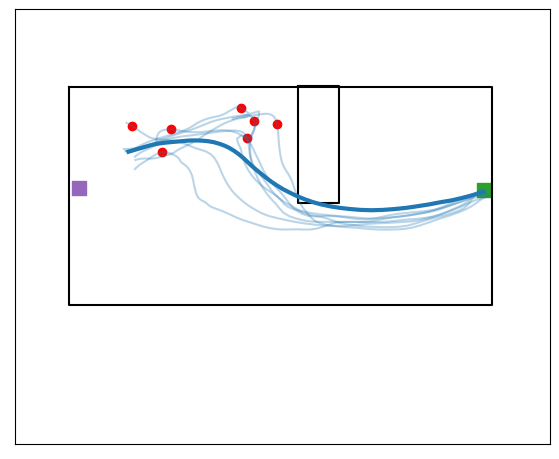

In [120]:
data = long[long.task == 'oa']
data = data[(data.distance_at_head_turn >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 1)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


ax.set_xticks([])
ax.set_yticks([])
mean_x = get_mean_of_df(data,'ts_nose_x_cm',50)
mean_y=get_mean_of_df(data,'ts_nose_y_cm',50)
trace_ax = data[(data.obstacle_cluster == 1)&(data.odd == 'left')].sample(7)     
plot_arena(trace_ax,ax,)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,1)
for ind,row in trace_ax.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = int(row.distance_at_head_turn_2_index)
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='tab:blue', alpha =.3 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')
ax.plot(mean_x,mean_y,c = 'tab:blue',linewidth=3.0)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_light_traces.pdf')

In [ ]:
row.ts_speed[:int(row.obstacle_ind)][:turn_index]

In [ ]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:]

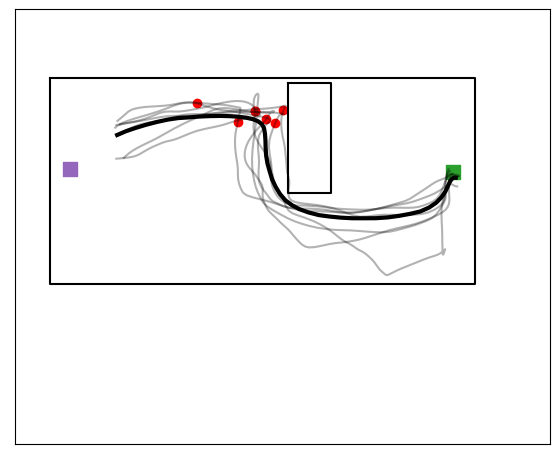

In [122]:
data = long[long.task == 'oadark']
data = data[(data.distance_at_head_turn >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 1)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


ax.set_xticks([])
ax.set_yticks([])
mean_x = get_mean_of_df(data,'ts_nose_x_cm',50)
mean_y=get_mean_of_df(data,'ts_nose_y_cm',50)
trace_ax = data[(data.obstacle_cluster == 1)&(data.odd == 'left')].sample(7)     
plot_arena(trace_ax,ax,)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,1)
for ind,row in trace_ax.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = int(row.distance_at_head_turn_2_index)
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='black', alpha =.3 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')
ax.plot(mean_x,mean_y,c = 'black',linewidth=3.0)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_dark_traces.pdf',dpi = 300)

In [ ]:
row.ts_speed[:int(row.obstacle_ind)][:turn_index]

In [ ]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][turn_index:]

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6),sharey =True)
light = long_nostart[long_nostart.task == 'oa']
light = light[(light.distance_at_head_turn_2 >= 0)&(light.distance_at_head_turn_2 <= 20) ]
sns.histplot(ax = ax[0], data=light,x = 'distance_at_head_turn_2',bins = 20,stat='proportion',color='tab:blue')


dark= long_nostart[long_nostart.task == 'oadark']
dark = dark[(dark.distance_at_head_turn_2 >= 0)&(dark.distance_at_head_turn_2 <= 20) ]
sns.histplot(ax = ax[1],data=dark,x = 'distance_at_head_turn_2',bins = 20,stat='proportion',color='grey')

ax[0].set_ylabel('proportion')

In [ ]:

data = long_nostart[long_nostart.task == 'oa']
data = data[(data.distance_at_head_turn_2 >= 0)&(data.distance_at_head_turn_2 <= 20) ]
sns.histplot(data=data,x = 'distance_at_head_turn_2',bins = 20,stat='proportion',color='tab:blue')


data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.distance_at_head_turn_2 >= 0)&(data.distance_at_head_turn_2 <= 20) ]
sns.histplot(data=data,x = 'distance_at_head_turn_2',bins = 20,stat='proportion',color='grey')

plt.ylabel('proportion')
plt.xlabel('distance at head turn (cm)')
plt.ylim(0,.25)
#symmetrize_y_axis(ax)

In [ ]:

data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.distance_at_head_turn_2 >= 0)&(data.distance_at_head_turn_2 <= 20) ]
sns.histplot(data=data,x = 'distance_at_head_turn_2',bins = 20,stat='proportion',color='grey')

plt.ylabel('proportion')
plt.xlabel('distance at head turn (cm)')
#symmetrize_y_axis(ax)

In [ ]:

data = long_nostart[long_nostart.task == 'oa']
data = data[(data.distance_at_head_turn >= 0)&(data.distance_at_head_turn <= 20) ]
sns.histplot(data=data,x = 'distance_at_head_turn_2',bins = 20,stat='proportion',color='tab:blue')

plt.ylabel('proportion')
plt.xlabel('average lateral error (cm)')
symmetrize_y_axis(ax)
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_light_histogram.pdf')

In [ ]:
data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.distance_at_head_turn >= 0)&(data.distance_at_head_turn <= 20) ]
sns.histplot(data=data,x = 'avg_lateral_error',bins = 20,stat='proportion',color='grey')
#plt.xlim(0,20)
#plt.ylim(0,.2)
plt.ylabel('proportion')
plt.xlabel('average lateral error (cm)')

In [ ]:
data = long_nostart[long_nostart.task == 'oa']
data = data[(data.distance_at_head_turn >= 0)&(data.distance_at_head_turn <= 20) ]
sns.histplot(data=data,x = 'avg_lateral_error',bins = 20,stat='proportion',color='tab:blue')
#plt.xlim(0,20)
#plt.ylim(0,.2)
plt.ylabel('proportion')
plt.xlabel('distance at head turn (cm)')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_light_histogram.pdf')

In [ ]:
data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.distance_at_head_turn >= 0)&(data.distance_at_head_turn <= 20) ]
sns.histplot(data=data,x = 'distance_at_head_turn',bins = 20,stat='proportion',color='grey')
plt.xlim(0,20)
plt.ylabel('proportion')
plt.xlabel('distance at head turn (cm)')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_dark_histogram.pdf')

In [ ]:
sns.histplot(data=data,x = 'avg_lateral_error',bins = 30,stat='proportion')
plt.xlim(0,-10)

In [ ]:
data = long

sns.violinplot(data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task')

In [ ]:
data = long_nostart
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.violinplot(data = data ,x='task' ,y = 'angle_at_head_turn',hue = 'task')

In [ ]:
data = long


sns.barplot(data = data ,x='task' ,y = 'angle_at_head_turn_2',hue = 'task',estimator = 'median')

In [ ]:
data = long


sns.barplot(data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'task',estimator = 'median')

In [ ]:
data = long


sns.barplot(data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task',estimator = 'median')

In [ ]:
data = long_nostart
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]

sns.barplot(data = data ,x='task' ,y = 'angle_at_head_turn',hue = 'task',estimator = 'mean')


In [ ]:
long

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']


sns.violinplot(data = data ,x='task' ,y = 'angle_at_head_turn',hue = 'task')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
order = ['oa','oadark']
sns.barplot(data = data ,x='task' ,y = 'angle_at_head_turn',hue = 'task',estimator = 'mean')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
order = ['oa','oadark']
sns.boxplot(data = data ,x='task' ,y = 'angle_at_head_turn',hue = 'task')


In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

#data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.barplot(data = data ,x='task' ,y = 'distance_traveled_at_head_turn',hue = 'task',estimator = 'median')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

#data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.barplot(data = data ,x='task' ,y = 'angle_at_head_turn',hue = 'task',estimator = 'median')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

#data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.barplot(data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task',estimator = 'median')

In [ ]:
data = long_con_nostart[(long_con_nostart.task == 'oa')&(long_con_nostart.consective_type == 2)]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[data.turn_to_obstacle=='towards']
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='tab:blue',hue = 'task',multiple='dodge',cbar=True,bins=20)

In [ ]:
data = long_con_nostart[(long_con_nostart.task == 'oa')&(long_con_nostart.consective_type == 0)]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[data.turn_to_obstacle=='towards']
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='tab:blue',hue = 'task',multiple='dodge',cbar=True,bins=20)

In [ ]:
data = long_nostart[long_nostart.task == 'oa']
#data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[data.turn_to_obstacle=='towards']
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='tab:blue',hue = 'task',multiple='dodge',cbar=True,bins=20,vmax=.1)

In [ ]:
data = long_nostart[long_nostart.task == 'oadark']
#data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[data.turn_to_obstacle=='towards']
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='tab:blue',hue = 'task',multiple='dodge',cbar=True,bins=20)

In [ ]:
data = long_nostart[(long_nostart.task == 'oa') & (long_nostart.turn_to_obstacle == 'towards')& (long_nostart.distance_at_head_turn >=0 )& (long_nostart.distance_at_head_turn <=20 )]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True,bins=20,vmax=.04)


In [ ]:
data = long_nostart[(long_nostart.task == 'oadark') & (long_nostart.turn_to_obstacle == 'towards')& (long_nostart.distance_at_head_turn >=0 )& (long_nostart.distance_at_head_turn <=20 )]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True,bins=20)

In [ ]:
data = long[long.task == 'oadark']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True,bins=20)

In [ ]:
data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'distance_at_head_turn',y ='angle_at_head_turn',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True,bins=20)

In [ ]:
data = joint[joint.task == 'oadark']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 30,stat='proportion',color='grey')

In [ ]:
data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 30,stat='proportion',color='grey')

In [ ]:
data = long_nostart[long_nostart.task == 'oadark']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 20,stat='proportion',color='grey')

In [ ]:
data = long_nostart[long_nostart.task == 'oa']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 20,stat='proportion',color='tab:blue')

In [ ]:
data = long_con_nostart[long_con_nostart.task == 'oa']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )&(data.consective_type == 0) ]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 20,stat='proportion',color='tab:blue')

In [ ]:
data = long_con_nostart[long_con_nostart.task == 'oa']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )&(data.consective_type == 2) ]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 20,stat='proportion',color='tab:blue')

In [ ]:
data = long_nostart[long_nostart.task == 'oa']
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
sns.histplot(data=data,x = 'angle_at_head_turn',bins = 30,stat='proportion',color='tab:blue')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

data = data[(data.distance_traveled_at_head_turn <=50)]
sns.violinplot(data = data ,x='task' ,y = 'distance_traveled_at_head_turn',hue = 'task')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

data = data[(data.distance_traveled_at_head_turn <=50)]
sns.barplot(data = data ,x='task' ,y = 'distance_traveled_at_head_turn',hue = 'task',estimator = 'median')

In [ ]:
distance_at_head_turn

In [ ]:
data = con_df[con_df.turn_to_obstacle=='towards']

data = data[(data.distance_traveled_at_head_turn <=50)&(data.consective_type ==2)]
sns.barplot(data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task',estimator = 'median')

In [ ]:
data = con_df[con_df.turn_to_obstacle=='towards']

data = data[(data.distance_traveled_at_head_turn <=50)&(data.consective_type ==2)]
sns.violinplot(data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task')

In [ ]:
data = con_df[con_df.turn_to_obstacle=='towards']

data = data[(data.distance_traveled_at_head_turn <=50)&(data.consective_type ==0)]
sns.violinplot(data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task')

In [ ]:
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

#data = data[(data.distance_traveled_at_head_turn <=50)&(data.consective_type ==0)]
sns.boxplot(data = data ,x='task' ,y = 'avg_lateral_error',hue = 'task')

In [ ]:
data

In [ ]:
fig,ax = plt.subplots(layout = 'tight')
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
ax.set_yticks([0,5,10])
ax.set_ylabel('distance at movement (cm)')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.distance_at_head_turn.median()
light_after= np.nanstd(light.groupby(['animal']).angle_to_corner_before.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).angle_to_corner_before.median().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.distance_at_head_turn.median()
dark_after= np.nanstd(dark.groupby(['animal']).angle_to_corner_before.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).angle_to_corner_before.median().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_bar.pdf',dpi = 300)

In [ ]:
fig,ax = plt.subplots(layout = 'tight')
data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn',hue = 'task',estimator = 'median',palette=['tab:blue','grey']) 
ax.set_yticks([0,5,10])
ax.set_ylabel('distance at turn (cm)')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\distance_at_head_turn/distance_at_head_turn_bar.pdf',dpi = 300)

In [ ]:
data = long_nostart[(long_nostart.task == 'oadark') & (long_nostart.turn_to_obstacle == 'towards')& (long_nostart.distance_at_head_turn >=0 )& (long_nostart.distance_at_head_turn <=20 )]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[(data.distance_traveled_at_head_turn <=50)]
sns.histplot(data=data,x = 'distance_traveled_at_head_turn',y ='avg_lateral_error',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True)

In [ ]:
data = long_nostart[(long_nostart.task == 'oa') & (long_nostart.turn_to_obstacle == 'towards')& (long_nostart.distance_at_head_turn >=0 )& (long_nostart.distance_at_head_turn <=20 )]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[(data.distance_traveled_at_head_turn <=50)]
sns.histplot(data=data,x = 'distance_traveled_at_head_turn',y ='avg_lateral_error',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True)

In [ ]:
data = long_nostart[(long_nostart.task == 'oa') & (long_nostart.turn_to_obstacle == 'towards')& (long_nostart.distance_at_head_turn >=0 )& (long_nostart.distance_at_head_turn <=20 )]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[(data.distance_traveled_at_head_turn <=50)]
sns.histplot(data=data,x = 'distance_at_head_turn',y ='distance_traveled_at_head_turn',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True)

In [ ]:
data = long_nostart[(long_nostart.task == 'oadark') & (long_nostart.turn_to_obstacle == 'towards')& (long_nostart.distance_at_head_turn >=0 )& (long_nostart.distance_at_head_turn <=20 )]
data = data[(data.angle_at_head_turn >= 0)&(data.angle_at_head_turn <= 90 )]
data = data[(data.distance_traveled_at_head_turn <=50)]
sns.histplot(data=data,x = 'distance_at_head_turn',y ='distance_traveled_at_head_turn',stat='proportion',color='grey',hue = 'task',multiple='dodge',cbar=True)